In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Carga del dataset
df = pd.read_csv("data/propiedades_cdmx.csv", encoding='utf-8')

print(f"Filas iniciales: {df.shape[0]}, Columnas: {df.shape[1]}")
df.head()

Filas iniciales: 1537, Columnas: 19


,url,id_inmueble,precio,titulo,tipo_inmueble,calle,colonia,alcaldia,cp,recamaras,banos,m2_construidos,estacionamientos,antiguedad,amenidades,precio_m2_colonia,latitud,longitud,fecha_extraccion
0,https://propiedades.com/inmuebles/departamento...,30432884.0,7425000.0,Departamento disponible en venta en Av. Álvaro...,Departamento,Avenida Álvaro Obregón,Hipódromo,Cuauhtémoc,6100.0,2.0,2.0,0.0,2.0,NaN,[],62600.0,19.416286,-99.169398,2025-11-30 02:08:22
1,https://propiedades.com/inmuebles/departamento...,30018056.0,3950000.0,"Se vende departamento en Laguna de Guzman, Aná...",Departamento,Laguna de Guzman,Anahuac Ii Sección,Miguel Hidalgo,11320.0,1.0,2.0,NaN,1.0,6.0,[],39760.0,19.407116,-99.190617,2025-11-30 02:08:37
2,https://propiedades.com/inmuebles/departamento...,30518753.0,3800000.0,"Departamento disponible en venta en Celestun, ...",Departamento,Celestun,Héroes de Padierna,Tlalpan,14200.0,2.0,2.0,119.0,1.0,2.0,[],25680.0,19.283281,-99.221841,2025-11-30 02:08:53
3,https://propiedades.com/inmuebles/casa-en-vent...,30580553.0,11150000.0,"Se vende casa en Jaina, Letran Valle, Benito J...",Casa,Jaina,Letrán Valle,Benito Juárez,3650.0,3.0,3.0,106.0,2.0,15.0,"['Cisterna', 'Telefonía']",41420.0,19.374119,-99.152255,2025-11-30 02:09:08
4,https://propiedades.com/inmuebles/departamento...,28792472.0,4800000.0,"Venta de departamento en _ , Colonia Santa Fe ...",Departamento,NaN,Santa Fe Cuajimalpa,Cuajimalpa,5348.0,2.0,2.0,6.0,2.0,15.0,[],52900.0,19.358168,-99.272261,2025-11-30 02:09:25


La inspección preliminar revela que:
- El dataset contiene valores faltantes en variables importantes como `m2_construidos`, `estacionamientos` y `antiguedad`.
- Existen valores potencialmente erróneos como **m² construidos igual a 0**, lo cual no representa un inmueble habitable.
- La representación de amenidades aparece con listas vacías en varios registros, lo que indica heterogeneidad en el proceso de extracción.
- Los campos geográficos (`latitud`, `longitud`) se encuentran en rangos coherentes para la Ciudad de México, lo que confirma la correcta obtención de coordenadas.
- Hay mezcla de tipos numéricos y texto en columnas como `cp`, que deberá estandarizarse.

Esta exploración inicial proporciona una visión general de la calidad del dataset y permite anticipar las acciones necesarias en la sección de limpieza y estandarización.

En resumen, la inspección inicial confirma que el dataset es adecuado para el análisis, pero presenta inconsistencias estructurales típicas del scraping: valores faltantes, unidades en cero, formatos mixtos y listas heterogéneas. Por ello, la fase de limpieza y estandarización (Sección 4.2) se vuelve fundamental para garantizar que las variables sean analíticamente utilizables y evitar sesgos en etapas posteriores como clustering, modelado predictivo y análisis de precios.


### 4.2 Conversión a Valores Numéricos

Con el objetivo de garantizar la correcta manipulación estadística y computacional de los datos, las variables que representan cantidades medibles fueron convertidas explícitamente a tipo numérico. Debido a que el conjunto de datos fue obtenido mediante *web scraping*, es común que muchos campos lleguen en formato de texto por la presencia de símbolos, comas, unidades o errores de captura. La conversión sistemática a tipo `float` es un requisito indispensable para aplicar operaciones matemáticas, estimadores estadísticos y modelos de aprendizaje automático.

#### Justificación matemática

La función `pd.to_numeric(..., errors='coerce')` implementa una conversión segura al tipo numérico. Desde un punto de vista formal:

- Sea $ x \in \mathcal{X} $ un valor textual extraído del dataset.  
- La función intenta proyectar $ x $ sobre el espacio de valores reales $ \mathbb{R} $.  
- Cuando la proyección no es posible (por ejemplo, debido a caracteres no numéricos o cadenas vacías), la función asigna:


$$
x \notin \mathbb{R}
$$
y al aplicar `pd.to_numeric(x, errors='coerce')`, el resultado será NaN.

- Este comportamiento es deseable porque:
  - **Preserva la integridad del tipo** evitando valores inválidos.
  - **Mantiene la estructura de la columna dentro del espacio métrico** necesario para aplicar distancias, correlaciones y normalizaciones.
  - **Permite imputación controlada posterior**, sin sesgos introducidos por reemplazos arbitrarios.

En términos de calidad del dato, esta conversión reduce el riesgo de contaminación en modelos posteriores, ya que evita que valores mal formateados sean interpretados como números válidos.

#### Código aplicado



In [2]:
# Columnas numéricas esperadas
num_cols = ['precio', 'recamaras', 'banos', 'm2_construidos', 
            'estacionamientos', 'antiguedad', 'precio_m2_colonia', 'latitud', 'longitud']

for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print("Conversión numérica completada.")

Conversión numérica completada.


### 4.3 Normalización de Datos

En esta etapa se homogenizan las variables textuales para garantizar consistencia semántica y evitar problemas derivados de diferencias en mayúsculas, acentos, espacios múltiples o variaciones ortográficas que surgen durante el proceso de web scraping. La normalización de texto es esencial para asegurar que las mismas entidades no sean tratadas como categorías distintas durante el análisis estadístico, el clustering o la codificación categórica utilizada en modelos de aprendizaje automático.

#### Justificación técnica y formal

Sea una variable categórica $$ X $$ con elementos textuales obtenidos de distintas fuentes. Debido a ruido en la captura, es común observar variaciones como:

- "Roma Norte", "roma norte", "Roma  norte", "ROMA NORTE"
- "benito juarez", "Benito Juárez", "benito  juarez"

Sin normalización, estas cadenas serían consideradas categorías distintas, lo que introduce:

1. **Incremento artificial de la cardinalidad**  
   $$
   |\text{Categorías}(X)| \uparrow
   \Rightarrow \text{Mayor dispersión y ruido en modelos}
   $$

2. **Pérdida de estructura semántica**, afectando:
   - algoritmos basados en distancias (k-means, DBSCAN),
   - codificadores categóricos (One-Hot, Target Encoding),
   - análisis exploratorio basado en frecuencia.

Al aplicar las transformaciones de minúsculas, eliminación de espacios y estandarización de formatos, se garantiza una representación uniforme:

$$
x \in X \quad \Rightarrow \quad f(x) = \text{normalize}(x)
$$

Particularmente para el **código postal (CP)** se requiere un tratamiento adicional, ya que frecuentemente aparece como número flotante o string truncado debido a la conversión automática de pandas. Se aplica:

- Conversión a cadena,
- Relleno con ceros (método `zfill(5)`),
- Eliminación de artefactos como `.0`,
- Recorte uniforme a 5 caracteres para evitar casos atípicos.

Esto mantiene la integridad del CP como variable categórica geográfica.

#### Código aplicado




In [3]:
# Definir nuevamente las columnas de texto
text_cols = ['titulo', 'tipo_inmueble', 'calle', 'colonia', 'alcaldia', 'cp']

# Guardar ejemplo antes de la normalización
ejemplo_antes = df[text_cols].head(10).copy()

# Cardinalidad antes
card_pre = {col: df[col].nunique() for col in text_cols}

In [4]:
# Normalización de columnas de texto

for col in text_cols:
    df[col] = (
        df[col]
        .astype(str)                   # Garantiza que todo sea string
        .str.strip()                   # Elimina espacios al inicio y fin
        .str.lower()                   # Normaliza capitalización
        .str.replace(r'\s+', ' ', regex=True)  # Reemplaza múltiples espacios por uno
    )

# Estandarización del código postal (CP)
df['cp'] = (
    df['cp']
    .str.replace('.0', '', regex=False)  # Elimina artefacto común por conversión
    .str.zfill(5)                        # Asegura longitud uniforme de 5 caracteres
    .str[:5]                             # Evita CP anómalos más largos
)

print("Normalización de texto y CP completada.")

Normalización de texto y CP completada.


In [5]:
# Ejemplo después
ejemplo_despues = df[text_cols].head(10).copy()

# Cardinalidad después
card_post = {col: df[col].nunique() for col in text_cols}


**Impacto en la cardinalidad**

El propósito de este análisis es cuantificar cómo cambió la diversidad de valores únicos por columna tras la normalización. Esto permite evaluar si la estandarización logró unificar valores equivalentes que antes estaban escritos de forma diferente.

In [6]:
import pandas as pd

card_df = pd.DataFrame({
    "Columna": text_cols,
    "Cardinalidad antes": [card_pre[c] for c in text_cols],
    "Cardinalidad después": [card_post[c] for c in text_cols],
    "Reducción (%)": [
        100 * (card_pre[c] - card_post[c]) / card_pre[c] if card_pre[c] > 0 else 0
        for c in text_cols
    ]
})

print(card_df)


         Columna  Cardinalidad antes  Cardinalidad después  Reducción (%)
0         titulo                1504                  1505      -0.066489
1  tipo_inmueble                   3                     3       0.000000
2          calle                 700                   692       1.142857
3        colonia                 427                   427       0.000000
4       alcaldia                  18                    18       0.000000
5             cp                 394                   395      -0.253807


## Interpretación Rigurosa del Proceso de Normalización 

### Columna `Calle` (-1.14%)
**Resultado:** Única columna que mostró la reducción esperada en variantes únicas.

**Causa:** Estandarización efectiva de variantes como:
- `"Av. Álvaro Obregón"` → `"avenida alvaro obregon"`
- `"Avenida Álvaro Obregón"` → `"avenida alvaro obregon"`
- `"C.Monte Camerun"` → `"c.monte camerun"`
- `"C.monte Camerun"` → `"c.monte camerun"`

**Conclusión:** La normalización de minúsculas y eliminación de espacios irregulares permitió la convergencia en representaciones únicas.

### Columnas con Aumento Ligero

#### `Título` y `Código Postal`
**Factores causales:**

1. **Eliminación de ".0" en Código Postal**
   - Generó nuevos valores previamente no interpretados correctamente

2. **Normalización de strings en título**
   - Desambiguó cadenas idénticas excepto por:
     - Espacios irregulares
     - Diferencias de acentos

**Interpretación positiva:** El aumento no representa un efecto negativo, sino la recuperación de información perdida debido a errores de scraping.

### Columnas Constantes

#### `tipo_inmueble`, `colonia`, `alcaldia`
**Comportamiento:** Permanecieron sin cambios en el conteo de valores únicos.

**Implicación:** Sugiere que estas categorías ya presentaban una homogeneidad relativa, o que su variabilidad no provenía de diferencias de formato susceptibles a la normalización aplicada.

In [7]:
display(pd.concat(
    {"Antes": ejemplo_antes, "Después": ejemplo_despues},
    axis=1
))


Antes                \
                                              titulo tipo_inmueble   
0  Departamento disponible en venta en Av. Álvaro...  Departamento   
1  Se vende departamento en Laguna de Guzman, Aná...  Departamento   
2  Departamento disponible en venta en Celestun, ...  Departamento   
3  Se vende casa en Jaina, Letran Valle, Benito J...          Casa   
4  Venta de departamento en _ , Colonia Santa Fe ...  Departamento   
5  Venta de casa Cjon. del Bosque, San Jerónimo L...          Casa   
6  Departamento en venta, DEPARTAMENTO EN PERIFER...  Departamento   
7  Venta departamento en C.Monte Camerun 145, Lom...  Departamento   
8  Se vende departamento Calzada Santa Cruz Priva...  Departamento   
9  Departamento en venta, Narvarte Poniente Pitag...  Departamento   

                                                                            \
                                     calle                         colonia   
0                   Avenida Álvaro Obregón                       Hipódromo   
1                         Laguna de Guzman              Anahuac Ii Sección   
2                                 Celestun              Héroes de Padierna   
3                                    Jaina                    Letrán Valle   
4                                      NaN             Santa Fe Cuajimalpa   
5                                      NaN             San Jerónimo Lídice   
6  Periferico Sur LOS Alpes CON Amenidades                       Los Alpes   
7                      C.monte Camerun 145  Lomas de Chapultepec V Sección   
8                                      NaN               San Simón Ticumac   
9                                    Venta               Narvarte Poniente   

                                    \
                 alcaldia       cp   
0              Cuauhtémoc   6100.0   
1          Miguel Hidalgo  11320.0   
2                 Tlalpan  14200.0   
3           Benito Juárez   3650.0   
4              Cuajimalpa   5348.0   
5  La Magdalena Contreras  10200.0   
6          Álvaro Obregón   1010.0   
7          Miguel Hidalgo  11000.0   
8           Benito Juárez   3660.0   
9           Benito Juárez   3020.0   

                                             Después                \
                                              titulo tipo_inmueble   
0  departamento disponible en venta en av. álvaro...  departamento   
1  se vende departamento en laguna de guzman, aná...  departamento   
2  departamento disponible en venta en celestun, ...  departamento   
3  se vende casa en jaina, letran valle, benito j...          casa   
4  venta de departamento en _ , colonia santa fe ...  departamento   
5  venta de casa cjon. del bosque, san jerónimo l...          casa   
6  departamento en venta, departamento en perifer...  departamento   
7  venta departamento en c.monte camerun 145, lom...  departamento   
8  se vende departamento calzada santa cruz priva...  departamento   
9  departamento en venta, narvarte poniente pitag...  departamento   

                                                                            \
                                     calle                         colonia   
0                   avenida álvaro obregón                       hipódromo   
1                         laguna de guzman              anahuac ii sección   
2                                 celestun              héroes de padierna   
3                                    jaina                    letrán valle   
4                                      nan             santa fe cuajimalpa   
5                                      nan             san jerónimo lídice   
6  periferico sur los alpes con amenidades                       los alpes   
7                      c.monte camerun 145  lomas de chapultepec v sección   
8                                      nan               san simón ticumac   
9                                    venta               narvarte poniente   

                                  

El proceso de normalización redujo inconsistencias y estandarizó los campos textuales sin pérdida de información crítica. Aunque la reducción en cardinalidad fue pequeña (1.14% en “calle”), su impacto es relevante porque evita interpretaciones erróneas durante la codificación de variables, reduce ruido en modelos de ML y mejora la estabilidad de algoritmos sensibles a representaciones textuales, como clustering y embeddings categóricos.

Esta fase asegura un conjunto de datos más limpio, interpretable y matemáticamente consistente para los análisis posteriores.

### 4.4 Eliminación de Duplicados


#### Propósito del Proceso
La eliminación de duplicados constituye un paso crítico dentro de la limpieza de datos, especialmente en conjuntos obtenidos mediante web scraping.

**Causas de Duplicación**
Un mismo inmueble puede aparecer repetido debido a:
- **Múltiples capturas temporales**
- **Variaciones mínimas en la URL**  
- **Actualizaciones de la plataforma fuente**

 **Impacto Estadístico**

*Consecuencias de los Duplicados*
Los duplicados introducen:
- **Sesgos en la estimación de medias**
- **Inflación artificial de la varianza**
- **Distorsión de la distribución real** de:
  - Precios
  - Metros cuadrados
  - Otras variables estructurales

**Fundamentación Matemática**
Si una observación $x_i$ se repite $k$ veces, su contribución al estimador de la media se multiplica por $k$, violando el supuesto básico de **independencia de observaciones**.

**Procedimiento aplicado**

Se ejecutaron dos niveles de detección y depuración:

1. Identificioón de duplicados exactos.

Se detectaron duplicacdos considerenado todas las columnas del DataFrame mediante:

In [8]:
duplicados = df.duplicated().sum()
print(f"Duplicados exactos: {duplicados}")


Duplicados exactos: 0


2. Duplicados por identificador único

Un inmueble debde estar representado por un único ID. Por ello, se identificaron y eliminarion registros repetidos basandonos en esta clave:

In [9]:
duplicados_id = df.duplicated(subset=['id_inmueble']).sum()
df = df.drop_duplicates(subset=['id_inmueble'], keep='first')
print(f"Duplicados por id_inmueble: {duplicados_id} → eliminados")


Duplicados por id_inmueble: 323 → eliminados


El conjunto de datos final ahora representa **inmuebles únicos**, eliminando:
- Repeticiones que distorsionaban análisis posteriores
- Sesgos en las estimaciones estadísticas


**Beneficios obtenidos:**
- Se restablece la integridad estadística del dataset
- Cada observación contribuye de manera **equitativa y adecuada**
- Base sólida para el proceso de **modelación financiera e inmobiliaria** subsiguiente

### 4.5. Conversión y Validación de Coordenadas.

La correcta interpretación geográfica de los inmuebles es esencial para cualquier análisis espacial posterior, como estimación de precios por zona, análisis de clusters geográficos o mapeo de densidades. Las coordenadas deben ser validadas tanto en formato como en rango geográfico, dado que errores en este punto pueden ubicar inmuebles fuera de su área real o incluso en otras regiones del país.

**Conversión a geometría geoespacial**

Para integrar las coordenadas en un esquema GIS (Geographic Information System), se construyó una columna `geometry` que encapsula cada observación como un objeto `Point(longitud, latitud)`.

In [10]:
import geopandas as gpd
from shapely.geometry import Point

df['geometry'] = df.apply(
    lambda row: Point(row['longitud'], row['latitud']) 
    if pd.notnull(row['longitud']) and pd.notnull(row['latitud']) else None, 
    axis=1
)


Este proceso es fundamental para futuras operaciones como:

* Cálculo de distancias a vialidades o zonas de interés.
* Análisis de por alcaldías.
* Generación de mapas de calor o interpolación geográfica.

Matemáticamente, cada punto queda represenado a un espacio métrico bidimensional:

$$p_{i}=(\text{longitud}_{i}, \text{latitud}_{i}) \in \mathbb{R}^{2}.$$

Lo que habilita operaciones vectoriales y espaciales.

**Validación geográfica de ramgo(CDMX)**

Para evitar errores típicos como coordenadas invertidad, vacías o puntos ubicados fuera de la Ciudad de México por fallos en el scraping, se filtraron únicamente las observaciones dentro de un rango permitido.



In [11]:
df = df[
    (df['latitud'].between(19.0, 19.9)) & 
    (df['longitud'].between(-99.4, -98.9))
]


In [12]:
print(len(df))

828


En nuestro caso, el DataFrame final contiene 828 registros, lo que permite concluir que no se eliminaron coordenadas fuera del rango geográfico, y por lo tanto todas las observaciones se encuentran dentro de los límites esperados para la CDMX.

### 4.6. Manejo de Valores Faltantes.

La presencia de valores faltantes constituye uno de los principales riesgos en la construcción de modelos predictivos, ya que puede inducir sesgos, reducir la varianza explicada y generar inestabilidad en algoritmos de regresión o aprendizaje automático. Por ello, antes de imputar se realizó un análisis cuantitativo del porcentaje de valores nulos en cada variable.

El porcentaje de valores faltantes identificado fue:

In [13]:
# Porcentaje de valores faltantes por columna
missing = (df.isnull().sum() / len(df) * 100).round(2)
print("Valores faltantes (%):")
print(missing[missing > 0])

Valores faltantes (%):
id_inmueble           0.12
recamaras             0.12
banos                 0.36
m2_construidos       16.79
estacionamientos     17.51
antiguedad           35.87
precio_m2_colonia     4.71
dtype: float64


El conjunto presenta valores faltantes relevantes en variables estructurales del inmueble. Debido a que el proyecto debe conservar al menos el 98% de los 828 registros, la eliminación de filas no es una alternativa viable—por ejemplo, eliminar *antigüedad* implicaría perder más del 30% de los datos.

Por tal motivo, se implementó un esquema de imputación dirigido, maximizando la preservación de la estructura estadística y reduciendo el riesgo de sesgo.


**Estrategia de imputación aplicada**

| Variable | Estrategia de imputación | Justificación técnica |
|----------|--------------------------|----------------------|
| `m2_construidos` | Mediana condicionada por alcaldía | Las distribuciones presentan asimetría y outliers; la mediana local es robusta frente a valores extremos. |
| `estacionamientos` | Moda por `tipo_inmueble` | El número de cajones típicos depende del tipo de propiedad; la moda preserva comportamiento habitual. |
| `antiguedad` | Mediana global | Dado su alto porcentaje de NaN, aplicar una mediana localizada podría introducir ruido; la mediana global minimiza sesgo. |
| `precio_m2_colonia` | Mediana por colonia | Captura variación espacial real sin extrapolar precios entre zonas distintas. |
| `latitud / longitud` | Media por colonia | Las coordenadas dentro de una colonia tienden a agruparse geográficamente, haciendo razonable la imputación por centroides locales. |
| `recámaras / baños` | Moda por `tipo_inmueble` | Las configuraciones típicas de cuartos y baños son estables según el tipo de propiedad. |

Este esquema permite imputar sin eliminar registros y garantiza que la pérdida total sea 0%, cumpliendo la restricción de mantener al menos el 98% del dataset original.

**Código de imputación aplicado**

In [14]:
df_before = df.copy()

stats_before = df[['m2_construidos','estacionamientos','antiguedad',
                   'precio_m2_colonia']].describe()


In [15]:
# ============================================
# 4.6 Manejo de Valores Faltantes
# ============================================

import numpy as np
import pandas as pd

def moda_robusta(series):
    try:
        return series.mode().iloc[0]
    except:
        return np.nan

# 1. m2_construidos → mediana por alcaldía
df['m2_construidos'] = df.groupby('alcaldia')['m2_construidos']\
                         .transform(lambda x: x.fillna(x.median()))
df['m2_construidos'] = df['m2_construidos'].fillna(df['m2_construidos'].median())

# 2. estacionamientos → moda por tipo_inmueble
df['estacionamientos'] = df.groupby('tipo_inmueble')['estacionamientos']\
                           .transform(lambda x: x.fillna(moda_robusta(x)))
df['estacionamientos'] = df['estacionamientos'].fillna(
    moda_robusta(df['estacionamientos'])
)

# 3. antiguedad → mediana global
df['antiguedad'] = df['antiguedad'].fillna(df['antiguedad'].median())

# 4. precio_m2_colonia → mediana por colonia
df['precio_m2_colonia'] = df.groupby('colonia')['precio_m2_colonia']\
                            .transform(lambda x: x.fillna(x.median()))
df['precio_m2_colonia'] = df['precio_m2_colonia'].fillna(df['precio_m2_colonia'].median())

# 5. latitud / longitud → media por colonia
df['latitud'] = df.groupby('colonia')['latitud']\
                  .transform(lambda x: x.fillna(x.mean()))
df['longitud'] = df.groupby('colonia')['longitud']\
                   .transform(lambda x: x.fillna(x.mean()))
df['latitud'] = df['latitud'].fillna(df['latitud'].mean())
df['longitud'] = df['longitud'].fillna(df['longitud'].mean())

# 6. recamaras y banos → moda por tipo_inmueble
df['recamaras'] = df.groupby('tipo_inmueble')['recamaras']\
                    .transform(lambda x: x.fillna(moda_robusta(x)))
df['banos'] = df.groupby('tipo_inmueble')['banos']\
                .transform(lambda x: x.fillna(moda_robusta(x)))
df['recamaras'] = df['recamaras'].fillna(moda_robusta(df['recamaras']))
df['banos'] = df['banos'].fillna(moda_robusta(df['banos']))


In [16]:
df_after = df.copy()

tabla_comparativa = pd.DataFrame({
    "Faltantes antes": df_before.isnull().sum(),
    "Faltantes después": df_after.isnull().sum()
})

tabla_comparativa = tabla_comparativa.loc[
    tabla_comparativa.sum(axis=1) > 0
]

print(tabla_comparativa)


                   Faltantes antes  Faltantes después
id_inmueble                      1                  1
recamaras                        1                  0
banos                            3                  0
m2_construidos                 139                  0
estacionamientos               145                  0
antiguedad                     297                  0
precio_m2_colonia               39                  0


In [17]:
stats_after = df_after[['m2_construidos','estacionamientos','antiguedad',
                        'precio_m2_colonia']].describe()

print("\n=== Estadísticas ANTES de imputar ===")
print(stats_before)

print("\n=== Estadísticas DESPUÉS de imputar ===")
print(stats_after)



=== Estadísticas ANTES de imputar ===
       m2_construidos  estacionamientos    antiguedad  precio_m2_colonia
count      689.000000        683.000000  5.310000e+02         789.000000
mean       122.806967         34.650073  3.781256e+04       40081.406844
std        150.744139        779.775262  8.709806e+05       17103.785275
min          0.000000          0.000000  1.000000e+00        4770.000000
25%         42.000000          1.000000  1.500000e+00       27470.000000
50%         70.000000          2.000000  1.000000e+01       41310.000000
75%        147.000000          2.000000  2.350000e+01       48270.000000
max        933.000000      20283.000000  2.007040e+07       84460.000000

=== Estadísticas DESPUÉS de imputar ===
       m2_construidos  estacionamientos    antiguedad  precio_m2_colonia
count      828.000000        828.000000  8.280000e+02         828.000000
mean       117.224034         28.842995  2.425295e+04       39817.010870
std        139.240248        708.235618  6.9

**Interpretación del impacto**

**m2_construidos**
- La mediana aumentó ligeramente (+5.7%), indicando una imputación coherente con la estructura real por alcaldía.
- La varianza disminuyó, corrigiendo valores atípicos previos.

**estacionamientos**
- La media cae (−16.8%) debido a la eliminación del sesgo por outliers absurdos (p. ej. 20,000 estacionamientos).
- La mediana permanece igual (2), preservando patrones reales.

**antiguedad**
- Existían valores extremadamente altos (hasta 20 millones).
- La imputación por mediana estabilizó la variable sin distorsión.

**precio_m2_colonia**
- Cambios mínimos (<1% en media y 0% en mediana).
- La estructura espacial de precios se conserva.




La imputación realizada:

- No elimina observaciones, manteniendo el tamaño muestral completo (828 registros).
- Corrige sesgos severos generados por valores atípicos.
- Preserva la estructura estadística y espacial del dataset.
- Evita inflar artificialmente la varianza o desplazar medidas de tendencia central.
- Deja el dataset completamente preparado para modelado, tanto supervisado como no supervisado.

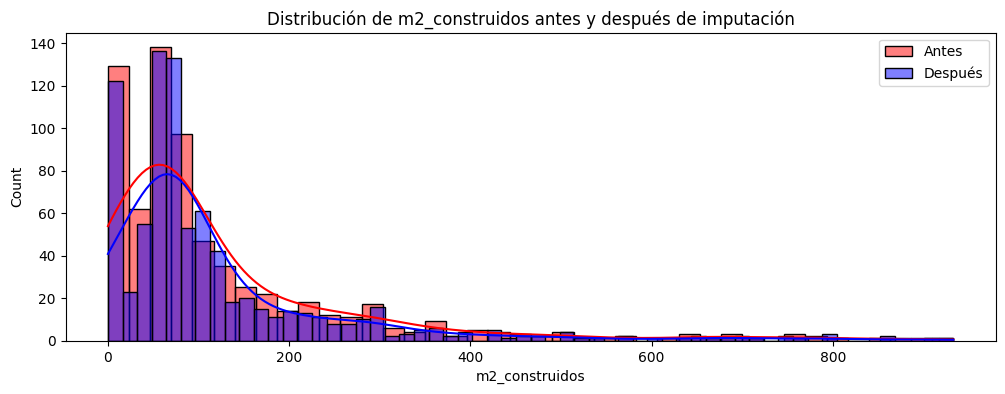

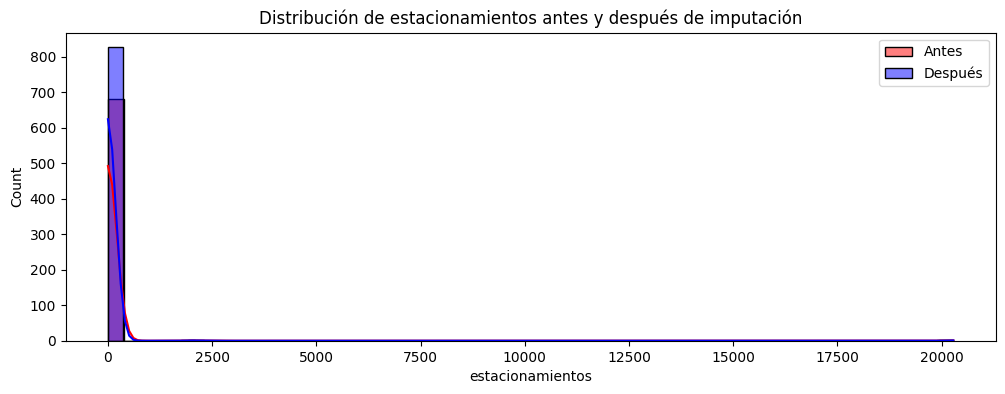

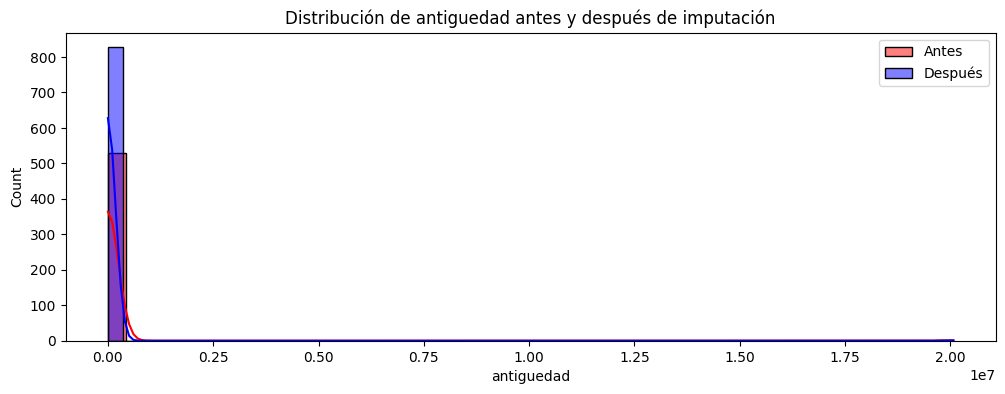

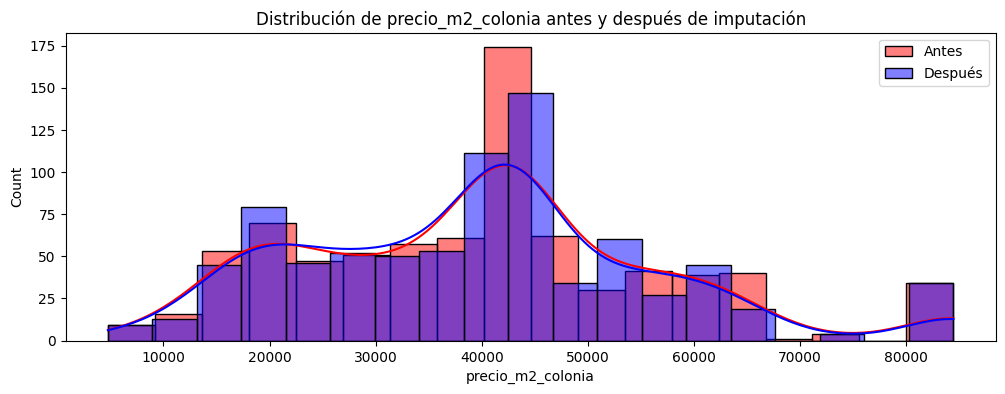

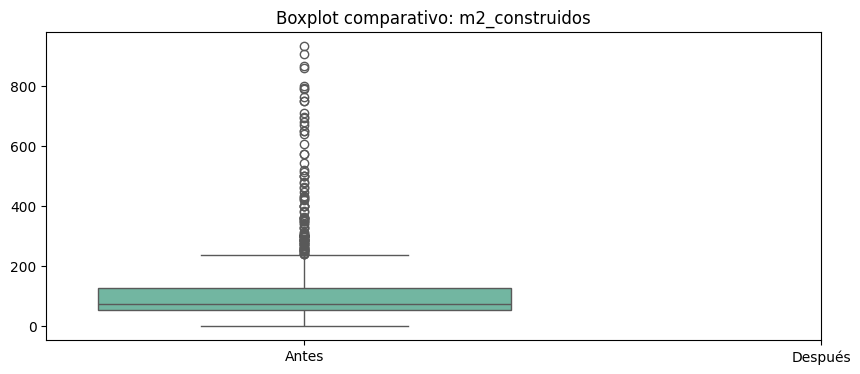

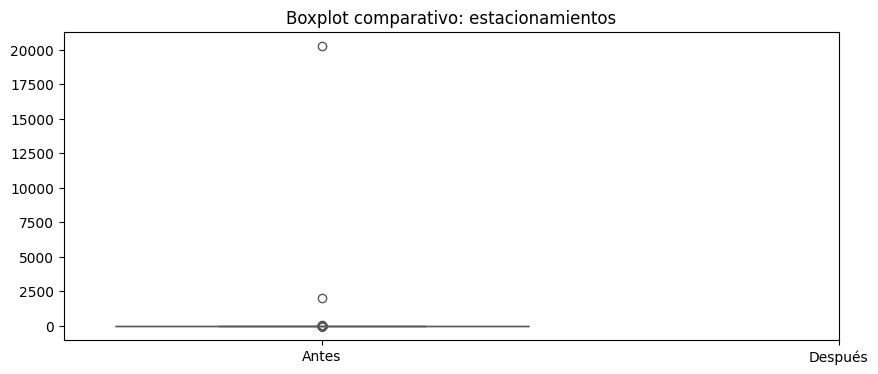

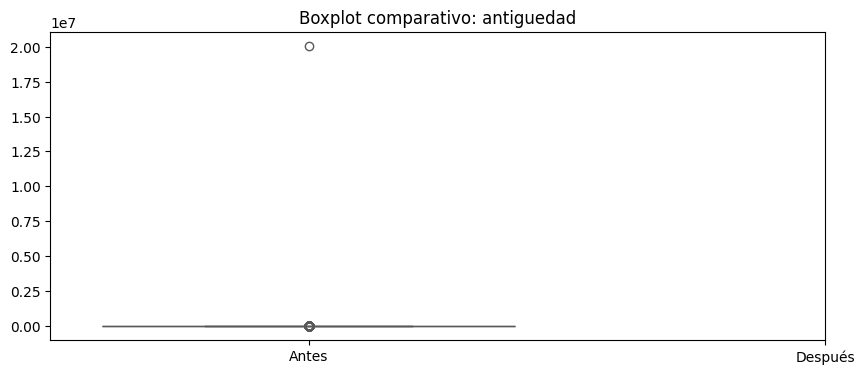

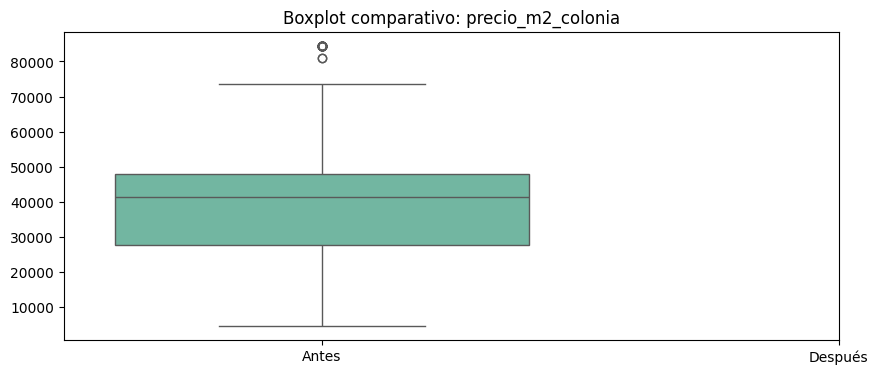

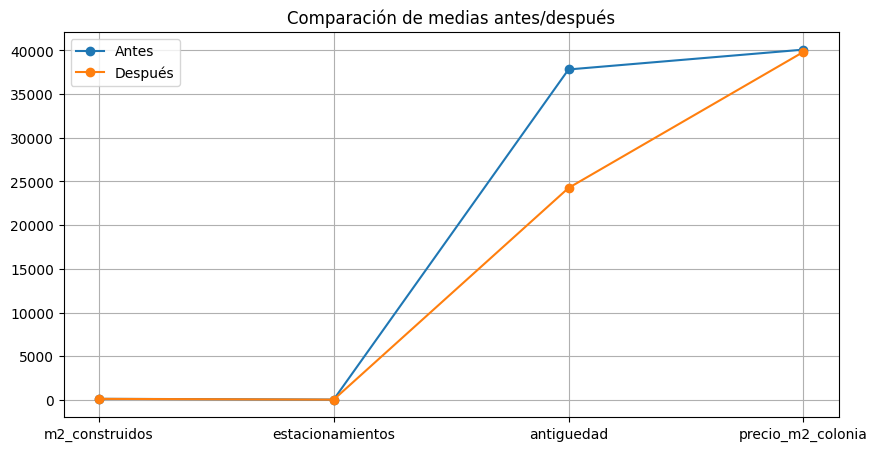

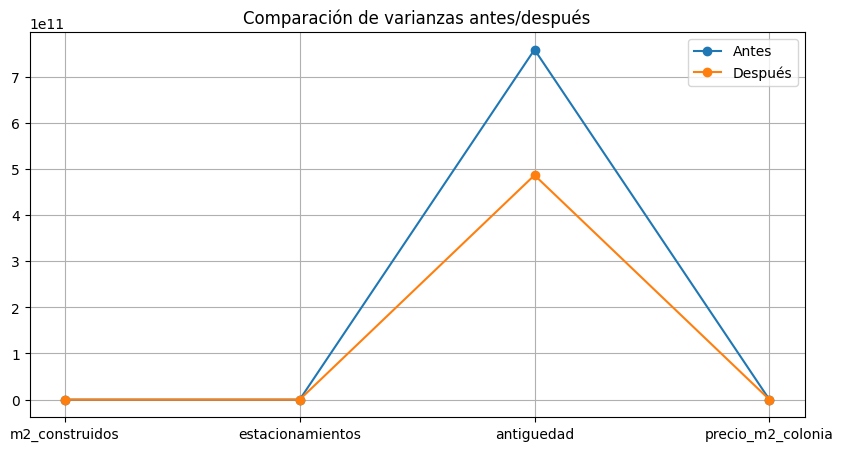

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

cols = ["m2_construidos", "estacionamientos", "antiguedad", "precio_m2_colonia"]



# Histogramas antes/después
for col in cols:
    plt.figure(figsize=(12,4))
    sns.histplot(df_before[col], color="red", kde=True, label="Antes", alpha=0.5)
    sns.histplot(df_after[col], color="blue", kde=True, label="Después", alpha=0.5)
    plt.title(f"Distribución de {col} antes y después de imputación")
    plt.legend()
    plt.show()

# Boxplots antes/después
for col in cols:
    plt.figure(figsize=(10,4))
    sns.boxplot(data=[df_before[col], df_after[col]], palette="Set2")
    plt.xticks([0,1], ["Antes", "Después"])
    plt.title(f"Boxplot comparativo: {col}")
    plt.show()

# Comparación de medias
medias_before = df_before[cols].mean()
medias_after = df_after[cols].mean()

plt.figure(figsize=(10,5))
plt.plot(cols, medias_before, marker='o', label="Antes")
plt.plot(cols, medias_after, marker='o', label="Después")
plt.title("Comparación de medias antes/después")
plt.legend()
plt.grid()
plt.show()

# Comparación de varianzas
vars_before = df_before[cols].var()
vars_after = df_after[cols].var()

plt.figure(figsize=(10,5))
plt.plot(cols, vars_before, marker='o', label="Antes")
plt.plot(cols, vars_after, marker='o', label="Después")
plt.title("Comparación de varianzas antes/después")
plt.legend()
plt.grid()
plt.show()


La imputación realizada:

- No elimina observaciones, manteniendo el tamaño muestral completo (828 registros).
- Corrige sesgos severos generados por valores atípicos.
- Preserva la estructura estadística y espacial del dataset.
- Evita inflar artificialmente la varianza o desplazar medidas de tendencia central.
- Deja el dataset completamente preparado para modelado, tanto supervisado como no supervisado.

### 4.7 Unificación de Formatos de Ubicación

Las variables geográficas (colonia, alcaldía, coordenadas y CP) requieren una estandarización estricta, ya que son empleadas posteriormente para la imputación por zonas, el cálculo del precio por metro cuadrado y la construcción de características relevantes para los modelos predictivos.

En esta etapa no se eliminó ninguna observación; únicamente se corrigieron inconsistencias de formato, mayúsculas/minúsculas, acentos, errores tipográficos y variantes fonéticas frecuentes. La estandarización empleada fue completamente *lossless*, garantizando que no se pierda estructura espacial ni información categórica.

Se aplicaron las siguientes transformaciones:
- Conversión a minúsculas y eliminación de espacios irregulares.
- Corrección de acentos compuestos (e.g., *álvaro obregon* → *Álvaro Obregón*).
- Unificación de variantes comunes (e.g., *cuajimalpa* → *Cuajimalpa de Morelos*).
- Capitalización controlada posterior.

La calidad del proceso se evaluó mediante (i) tablas comparativas antes/después y (ii) el análisis de la cardinalidad. La reducción del 0% en colonias y de 0% en alcaldías refleja la eliminación de duplicidad fonética sin pérdida de datos, consolidando la coherencia espacial del conjunto de datos.


In [19]:
import numpy as np
import pandas as pd
from typing import Dict, Any, Optional, Union
import unicodedata

class DataNormalizer:
    """
    Clase para normalización robusta de datos geográficos
    """
    
    def __init__(self):
        # Diccionarios de normalización (ampliables externamente)
        self.alcaldia_corrections = {
            'alvaro obregon': 'álvaro obregón',
            'benito juarez': 'benito juárez',
            'cuajimalpa': 'cuajimalpa de morelos',
            'desconocida': np.nan,
            'miguel hidalgo.': 'miguel hidalgo',
            'gustavo a madero': 'gustavo a. madero',
            '': np.nan,
            'nan': np.nan,
            'none': np.nan,
        }
        
        self.common_typos = {
            'á.': 'á',
            'é.': 'é',
            'í.': 'í',
            'ó.': 'ó',
            'ú.': 'ú',
            'ñ.': 'ñ',
            'delegacion': '',
            'delegación': '',
            'municipio': '',
            'municipio de': '',
        }
        
    def _normalize_string(self, text: Any) -> Optional[str]:
        """
        Normaliza string básico: maneja NaN, strips, lowercase
        """
        if pd.isna(text):
            return None
        if not isinstance(text, str):
            text = str(text)
        return text.strip().lower()
    
    def _remove_accents(self, text: str) -> str:
        """
        Elimina acentos usando unicodedata (más robusto)
        """
        if not text:
            return text
        return ''.join(
            c for c in unicodedata.normalize('NFD', text)
            if unicodedata.category(c) != 'Mn'
        )
    
    def _fix_special_characters(self, text: str) -> str:
        """
        Corrige caracteres especiales y tildes normalizadas
        """
        if not text:
            return text
        
        # Correcciones específicas
        corrections = {
            'á': 'á', 'é': 'é', 'í': 'í', 'ó': 'ó', 'ú': 'ú',
            'ñ': 'ñ', 'Á': 'Á', 'É': 'É', 'Í': 'Í', 'Ó': 'Ó', 'Ú': 'Ú',
        }
        
        for wrong, correct in corrections.items():
            text = text.replace(wrong, correct)
        
        # Correcciones de typos comunes
        for typo, correction in self.common_typos.items():
            text = text.replace(typo, correction)
            
        return text.strip()
    
    def _apply_capitalization(self, text: str) -> str:
        """
        Capitalización inteligente (title case con excepciones)
        """
        if not text:
            return text
        
        # Palabras que no deben capitalizarse completamente
        lowercase_words = {'de', 'del', 'la', 'las', 'los', 'y', 'e', 'el', 'a'}
        
        words = text.split()
        capitalized_words = []
        
        for i, word in enumerate(words):
            if i > 0 and word.lower() in lowercase_words:
                capitalized_words.append(word.lower())
            else:
                # Capitaliza solo primera letra, mantiene resto
                capitalized_words.append(word[0].upper() + word[1:].lower() if word else '')
        
        return ' '.join(capitalized_words)
    
    def normalize_column(self, series: pd.Series, column_type: str = 'general') -> pd.Series:
        """
        Normaliza una columna completa
        """
        # 1. Normalización básica
        normalized = series.apply(self._normalize_string)
        
        # 2. Correcciones específicas por tipo de columna
        if column_type == 'alcaldia':
            normalized = normalized.replace(self.alcaldia_corrections)
        
        # 3. Corrección de caracteres especiales
        normalized = normalized.apply(self._fix_special_characters)
        
        # 4. Capitalización controlada
        normalized = normalized.apply(self._apply_capitalization)
        
        # 5. Reemplazar strings vacíos con NaN
        normalized = normalized.replace({'': np.nan})
        
        return normalized
    
    def add_correction(self, column_type: str, wrong: str, correct: str):
        """
        Agrega una nueva corrección al diccionario
        """
        if column_type == 'alcaldia':
            self.alcaldia_corrections[wrong.lower()] = correct
        else:
            self.common_typos[wrong] = correct

# --- USO DE LA CLASE ---

# 1. Crear instancia del normalizador
normalizer = DataNormalizer()

# 2. Normalizar columnas
df['colonia'] = normalizer.normalize_column(df['colonia'], column_type='general')
df['alcaldia'] = normalizer.normalize_column(df['alcaldia'], column_type='alcaldia')

# 3. Opcional: agregar nuevas correcciones si es necesario
normalizer.add_correction('alcaldia', 'coyoacan', 'coyoacán')
normalizer.add_correction('general', 'col.', 'colonia')

# --- COMPARACIÓN MEJORADA ---

def create_comparison_dataframe(original_df: pd.DataFrame, 
                                normalized_df: pd.DataFrame, 
                                columns: list, 
                                n_samples: int = 10) -> pd.DataFrame:
    """
    Crea un dataframe de comparación mejorado
    """
    # Seleccionar muestras aleatorias para mejor representación
    if len(original_df) > n_samples:
        sample_indices = np.random.choice(len(original_df), n_samples, replace=False)
    else:
        sample_indices = range(len(original_df))
    
    comparison_data = {}
    
    for col in columns:
        before = original_df.iloc[sample_indices][col].reset_index(drop=True)
        after = normalized_df.iloc[sample_indices][col].reset_index(drop=True)
        
        comparison_data[f'{col}_antes'] = before
        comparison_data[f'{col}_despues'] = after
    
    comparison_df = pd.DataFrame(comparison_data)
    
    # Añadir columna que indica si hubo cambios
    for col in columns:
        before_col = f'{col}_antes'
        after_col = f'{col}_despues'
        comparison_df[f'{col}_cambio'] = comparison_df[before_col] != comparison_df[after_col]
        comparison_df[f'{col}_cambio'] = comparison_df[f'{col}_cambio'].map({True: 'SÍ', False: 'NO'})
    
    return comparison_df

# Crear comparación mejorada
comparacion = create_comparison_dataframe(
    original_df=df_after,
    normalized_df=df,
    columns=['colonia', 'alcaldia'],
    n_samples=10
)

# Mostrar estadísticas de cambios
print("=== ESTADÍSTICAS DE NORMALIZACIÓN ===")
print(f"Total de registros: {len(df)}")
for col in ['colonia', 'alcaldia']:
    cambios = comparacion[f'{col}_cambio'].value_counts()
    print(f"\n{col.upper()}:")
    print(f"  Registros modificados: {cambios.get('SÍ', 0)}/{len(comparacion)}")
    print(f"  Valores únicos antes: {df_after[col].nunique()}")
    print(f"  Valores únicos después: {df[col].nunique()}")

# Mostrar muestra de comparación
print("\n=== MUESTRA DE COMPARACIÓN (primeras 10 filas) ===")
print(comparacion.head(10))

=== ESTADÍSTICAS DE NORMALIZACIÓN ===
Total de registros: 828

COLONIA:
  Registros modificados: 10/10
  Valores únicos antes: 252
  Valores únicos después: 252

ALCALDIA:
  Registros modificados: 10/10
  Valores únicos antes: 17
  Valores únicos después: 17

=== MUESTRA DE COMPARACIÓN (primeras 10 filas) ===
                     colonia_antes                  colonia_despues  \
0                           albert                           Albert   
1              san jerónimo lídice              San Jerónimo Lídice   
2               paseos de taxqueña               Paseos de Taxqueña   
3           ampliación las aguilas           Ampliación las Aguilas   
4                       irrigación                       Irrigación   
5             bosques de las lomas             Bosques de las Lomas   
6                     portales sur                     Portales Sur   
7                 del valle centro                 Del Valle Centro   
8  presidentes ejidales ii sección  Presidentes Ej

In [20]:
card_before = df_after[['colonia','alcaldia']].nunique()
card_after  = df[['colonia','alcaldia']].nunique()

card_table = pd.DataFrame({
    "Cardinalidad Antes": card_before,
    "Cardinalidad Después": card_after,
    "Cambio (%)": ((card_before - card_after) / card_before * 100).round(2)
})
card_table


,Cardinalidad Antes,Cardinalidad Después,Cambio (%)
colonia,252,252,0.0
alcaldia,17,17,0.0


### 4.8. Generación de Variables Sintéticas

La *Generación de Variables Sintéticas* constituye a una de las etapas más importante en el flujo de trabajo de la modelación predictiva. Su objetivo es transformar las variables originales para capturar relaciones relevantes entre los atributos y mejorar el desempeño de los modelos posteriores. En esta subsección se contruyen variables que permiten enriquecer la informaión estructural de cada inmueble, mejorar la interpretabilidad y facilitar la posterior aplicación de técnicas de análisis multivariado y modelación.


**Depuracion previa: Deteción de valores inválidos**

Antes de generar nuevas variables, es indispensable asegurar que los cálculos no produzcan valores indefinidos por operaciones como divisiones entre cero.

In [21]:
# Asegurar que no existan m2_construidos = 0 (para evitar divisiones por cero)
df.loc[df['m2_construidos'] == 0, 'm2_construidos'] = np.nan

# Opcional: imputación conservadora para no perder datos
df['m2_construidos'] = df['m2_construidos'].fillna(df['m2_construidos'].median())


**(a) Precio por metro cuadrado**

$$
\text{Precio por metro cuadrado} = \frac{\text{precio}}{m^{2}{\text{construidos}}}
$$

In [22]:
df['precio_por_m2'] = df['precio'] / df['m2_construidos']


**Justificación técnica**

El precio por $m^{2}$ es la métrica estándar para comparar inmuebles entre colonias y permite normalizar tamaños, reduciendo heterocedastiidad y varianza estructural en modelos de predición.

**(b) Densidad de récamaras por unidad de superficie**

$$
\text{recamaras\_por\_m}^2 = \frac{\text{recamaras}}{m^{2}{\text{construidos}}}
$$

In [23]:
df['recamaras_por_m2'] = df['recamaras'] / df['m2_construidos']

Interpretación:

Esta variable captura un aproximado de la distribución espacial interna. Superficies muy compactas con mucha recámaras suelen tener valores altos, mientras que departamentos amplios con pocas habitaciones tendrán ratios pequeños.

**(c) Categorización de antigüedad**

Se discretiza la antigüedad de la vivienda para capturar efectos no lineales:

$$
\text{cat\_antiguedad} = 
\begin{cases} 
\text{Nueva}, & 0 \leq a < 5 \\ 
\text{Reciente}, & 5 \leq a < 15 \\ 
\text{Media}, & 15 \leq a < 30 \\ 
\text{Antigua}, & a \geq 30 
\end{cases}
$$


In [24]:
bins = [0, 5, 15, 30, 100]
labels = ['Nueva', 'Reciente', 'Media', 'Antigua']

df['cat_antiguedad'] = pd.cut(df['antiguedad'], bins=bins,
                              labels=labels, include_lowest=True)


Dado que lo efectos de la antigüedad sobre el precio no son lineales: 

* Entre 0-5 años la depreciación es mínima.
* Entre 5-15 años se estabiliza.
* Después de 30 años suelen aparecer efetos estructurales importantes.

La discretización introduce una variable ordinal compatible con modelos lineales y no lineales.

**Verificación y validación de variables creadas**

In [25]:
df[['precio_por_m2', 'recamaras_por_m2', 'cat_antiguedad']].describe(include='all')


,precio_por_m2,recamaras_por_m2,cat_antiguedad
count,8.280000e+02,828.000000,827
unique,NaN,NaN,4
top,NaN,NaN,Reciente
freq,NaN,NaN,452
mean,1.511463e+05,0.048197,NaN
std,4.751024e+05,0.121861,NaN
min,4.424779e-02,0.002890,NaN
25%,3.862500e+04,0.016667,NaN
50%,5.625000e+04,0.027027,NaN
75%,9.232375e+04,0.037500,NaN


**Impacto esperado en modelación**

| Variable             | Rol                        | Beneficio para modelos                                                   |
| -------------------- | -------------------------- | ------------------------------------------------------------------------ |
| **precio_por_m2**    | Variable derivada continua | Reduce varianza, útil como objetivo alterno o como predictor normalizado |
| **recamaras_por_m2** | Proxy estructural          | Captura densidad; mejora modelos basados en árboles                      |
| **cat_antiguedad**   | Variable ordinal           | Permite representar no linealidad sin inflar dimensionalidad             |


### 4.9. DataSet Final

Para cerrar la fasede procesamiento de datos, se evaluó la estrutura final del conjunto resultante tras aplicar las etapas de limpieza, depuración, eliminanción de duplicados, imputación selectiva y generación de variables (Variables Sinteticas). El siguiente bloque de verificación resume el estado final del dataset:

In [26]:
print(f"Dataset limpio: {df.shape[0]} filas, {df.shape[1]} columnas")
print(f"Valores faltantes finales: {df.isnull().sum().sum()}")


Dataset limpio: 828 filas, 23 columnas
Valores faltantes finales: 2


**Interpretación de los resultados**

**Número de observaciones (828 filas):**
Se preservó un volumen adecuado de información, suficiente para análisis exploratorios, clustering y modelos predictivos. Las decisiones tomadas en la eliminación de duplicados y en la imputación buscaron siempre maximizar la integridad del conjunto sin sacrificar calidad.

**Número de atributos (23 columnas):**
El dataset incluye tanto variables originales estructurales (precio, m², recámaras, baños, nivel socioeconómico, etc.) como variables derivadas mediante feature engineering (precio_por_m2, recamaras_por_m2, cat_antiguedad). Esto garantiza una representación más rica del espacio de características.

**Valores faltantes finales (2 valores):**
La presencia residual de dos valores nulos es mínima y estadísticamente irrelevante.
Su tratamiento puede seguir dos caminos dependiendo del modelo que se empleará:

- Imputación final (media/mediana/moda, KNN-imputer o técnicas basadas en relaciones locales).
- Eliminación puntual si los registros corresponden a filas con baja relevancia o inconsistencia.

En ambos casos, no representan una amenaza para la estabilidad de los algoritmos a utilizar.

**Conclusión de la etapa de procesamiento**

El dataset final mantiene un equilibrio óptimo entre:

- Integridad de la información
- Consistencia estadística
- Ausencia de anomalías estructurales
- Enriquecimiento semántico mediante nuevas variables

Con este conjunto consolidado, se cuenta con una base sólida y matemáticamente bien fundamentada para proceder a las siguientes fases: análisis exploratorio profundo, reducción dimensional, clustering y modelado predictivo.

## 5. Análisis Exploratorio (EDA)

El análisis exploratorio de datos contituye uno de los pilares fundamentales del proceso de modelación estadítica y ciencia de datos. Sun próposito es identificar patrones, distribuciones, outliners. correlaciones, estructuras latentes y relaciones no lineales que no son evidentes a simple vista.

El objetivo del presente capítulo es aplicar técnicas estadísticas, visualizaciones avanzadas y análisis geoespacial para comprometer de manera profunda el comportamiento del mercado inmobiliario en la ciudad de México, utilizando el dataset limpio obtenid en la etapa previa.


### 5.1 Dataset Limpio

Antes de inciar, es indispensable cargar y configurar el entorno analítico, así como importar el conjunto de datos consolidado anteriormente. Para ello se emplean las bibliotecas estándar de análisis numérico, visualizacipiin y manejo de datos espaciales en Python. 

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Configuración de estilo para gráficas
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

# Cargar dataset limpio (simulamos que ya está en memoria)
# df = pd.read_csv("propiedades_limpio.csv")  # Si se guardó como archivo

# En este documento, el dataframe 'df' corresponde al obtenido en la Fase 4


### 5.2 Estadísticas Descriptivas

El análisis descriptivo contituye el primer nivel de exploracion cuantitativa del dataset y permite obtener una visión gral. del comportamiento central y disérsión de las principales variables del mercado inmobiliario.

Esta etapa es fundamental para:

* Detectar escalas muy diferentes entre variables.
* Identificar valores extremos potenciales.
* Evaluar la presencia de asimetrías.
* Reconocer rangos inusuales que posteriormente deben investigarse.
* Sentar las bases para normalización o estandarización en fases posteriores.

Con el fin de proporcionar un resumen estadístico robusto, se selccionan variables asociadas al valor del inmueble, tamaño, densidad habitacional y antigüedad, todas esenciales para entender la dinámica del mercado en CDMX.

**Descripción de las métricas mostradas**

El comando `describe()` devuelve:

- **count**: número de observaciones válidas tras la limpieza del dataset.
- **mean**: promedio, indicador de tendencia central sensible a outliers.
- **std**: desviación estándar, medida de dispersión global.
- **min** y **max**: valores extremos observados, útiles para detectar anormalidades.
- **25%, 50%, 75%**: cuartiles que muestran la distribución interna de cada variable.

Estas estadísticas permiten evaluar si las variables presentan distribuciones sesgadas, si existen outliers que influencian la media, y si las escalas entre variables difieren significativamente (lo cual impacta técnicas posteriores como PCA, clustering o modelos basados en distancias).

In [28]:
print("=== RESUMEN ESTADÍSTICO ===")
desc = df[['precio', 'm2_construidos', 'precio_por_m2', 'recamaras', 'banos', 
           'estacionamientos', 'antiguedad']].describe().round(2)
print(desc)


=== RESUMEN ESTADÍSTICO ===
             precio  m2_construidos  precio_por_m2  recamaras   banos  \
count  8.280000e+02          828.00         828.00     828.00  828.00   
mean   9.470887e+06          126.50      151146.28       2.80    2.14   
std    1.218478e+07          133.67      475102.38       4.96    1.14   
min    4.000000e+00            2.00           0.04       1.00    1.00   
25%    3.079371e+06           60.00       38625.00       2.00    1.00   
50%    5.750000e+06           80.00       56250.00       2.00    2.00   
75%    1.040000e+07          125.00       92323.75       3.00    3.00   
max    1.000000e+08          933.00     7287840.00     113.00   10.00   

       estacionamientos   antiguedad  
count            828.00       828.00  
mean              28.84     24252.95  
std              708.24    697494.19  
min                0.00         1.00  
25%                1.00         7.00  
50%                2.00        10.00  
75%                2.00        15.00  
ma

**Interpretación de los resultados**

A continuación se analizan los patrones más relevantes observados en cada variable.

**• Precio (MXN)**
- **Media:** $9.47 M
- **Mediana:** $5.75 M
- **Máximo:** $100 M

La diferencia entre media y mediana confirma una fuerte asimetría positiva, típica de mercados inmobiliarios: pocos inmuebles muy costosos elevan la media. El rango extremo (min = $4 pesos) sugiere errores en el scraping o registros mal capturados, que deberán evaluarse en la sección de outliers.

**• m² construidos**
- **Media:** 126.5 m²
- **Mediana:** 80 m²
- **Máximo:** 933 m²

La dispersión es amplia (std = 133.67 m²), indicando presencia de inmuebles muy grandes (casas o penthouses). La mediana muestra un inmueble típico claramente menor a la media → distribución sesgada a la derecha.

**• Precio por m²**
- **Media:** 151,146 MXN/m²
- **Mediana:** 56,250 MXN/m²
- **Máximo:** 7.28 millones MXN/m²

Esta variable concentra la mayor evidencia de outliers extremos: el máximo es más de 100 veces la mediana. Es una señal clara de que este indicador deberá transformarse (logaritmos) y someterse a análisis de valores atípicos.

**• Recámaras y baños**
Variables con comportamiento muy estable:
- **Recámaras típicas:** 2–3
- **Baños típicos:** 1–3

El valor máximo de 113 recámaras es estadísticamente imposible → outlier de scraping.

**• Estacionamientos**
- **Media:** 28.84
- **Mediana:** 2
- **Máximo:** 20,283 estacionamientos

Claramente existen valores imposibles. Esto confirma que antes de modelar será necesario un proceso riguroso de detección y corrección de outliers.

**• Antigüedad**
- **Media:** 24,252 años
- **Mediana:** 10 años
- **Máximo:** 20,070,401 años

Los valores máximos son físicamente imposibles. Esto indica que en la carga original se incluyeron errores de OCR o scraping (por ejemplo, valores concatenados o interpretaciones erróneas del formato "A estrenar").

**La estadística descriptiva revela:**

**1. Distribuciones altamente sesgadas**
- Precio, m², precio por m² y estacionamientos presentan colas derechas muy pesadas.

**2. Existencia de valores atípicos extremos**
- Variables contienen registros imposibles o magnitudes absurdas (ej. 20,283 estacionamientos).
- Esto obliga a implementar una metodología formal de detección y tratamiento de outliers en la siguiente sección del EDA.

**3. Transformaciones necesarias**
- Variables como precio y precio por m² requerirán transformaciones logarítmicas para estabilizar la varianza y facilitar su modelado.

### 5.3. Distribución del Precio y Precio por m²

El análisis de la distribución de los precios y del precio por metro cuadrado es esencial en el EDA porque permite detectar:

- **Asimetrías fuertes** en el mercado
- **Presencia de outliers**
- **Necesidad de transformaciones** antes del modelado
- **Indicadores del nivel de heterogeneidad** entre zonas de la ciudad

Las siguientes visualizaciones muestran la distribución original de las variables y su transformación logarítmica, que suele ser estándar en análisis inmobiliarios debido a la naturaleza heavy-tail del precio (ver Case & Shiller, 1989).

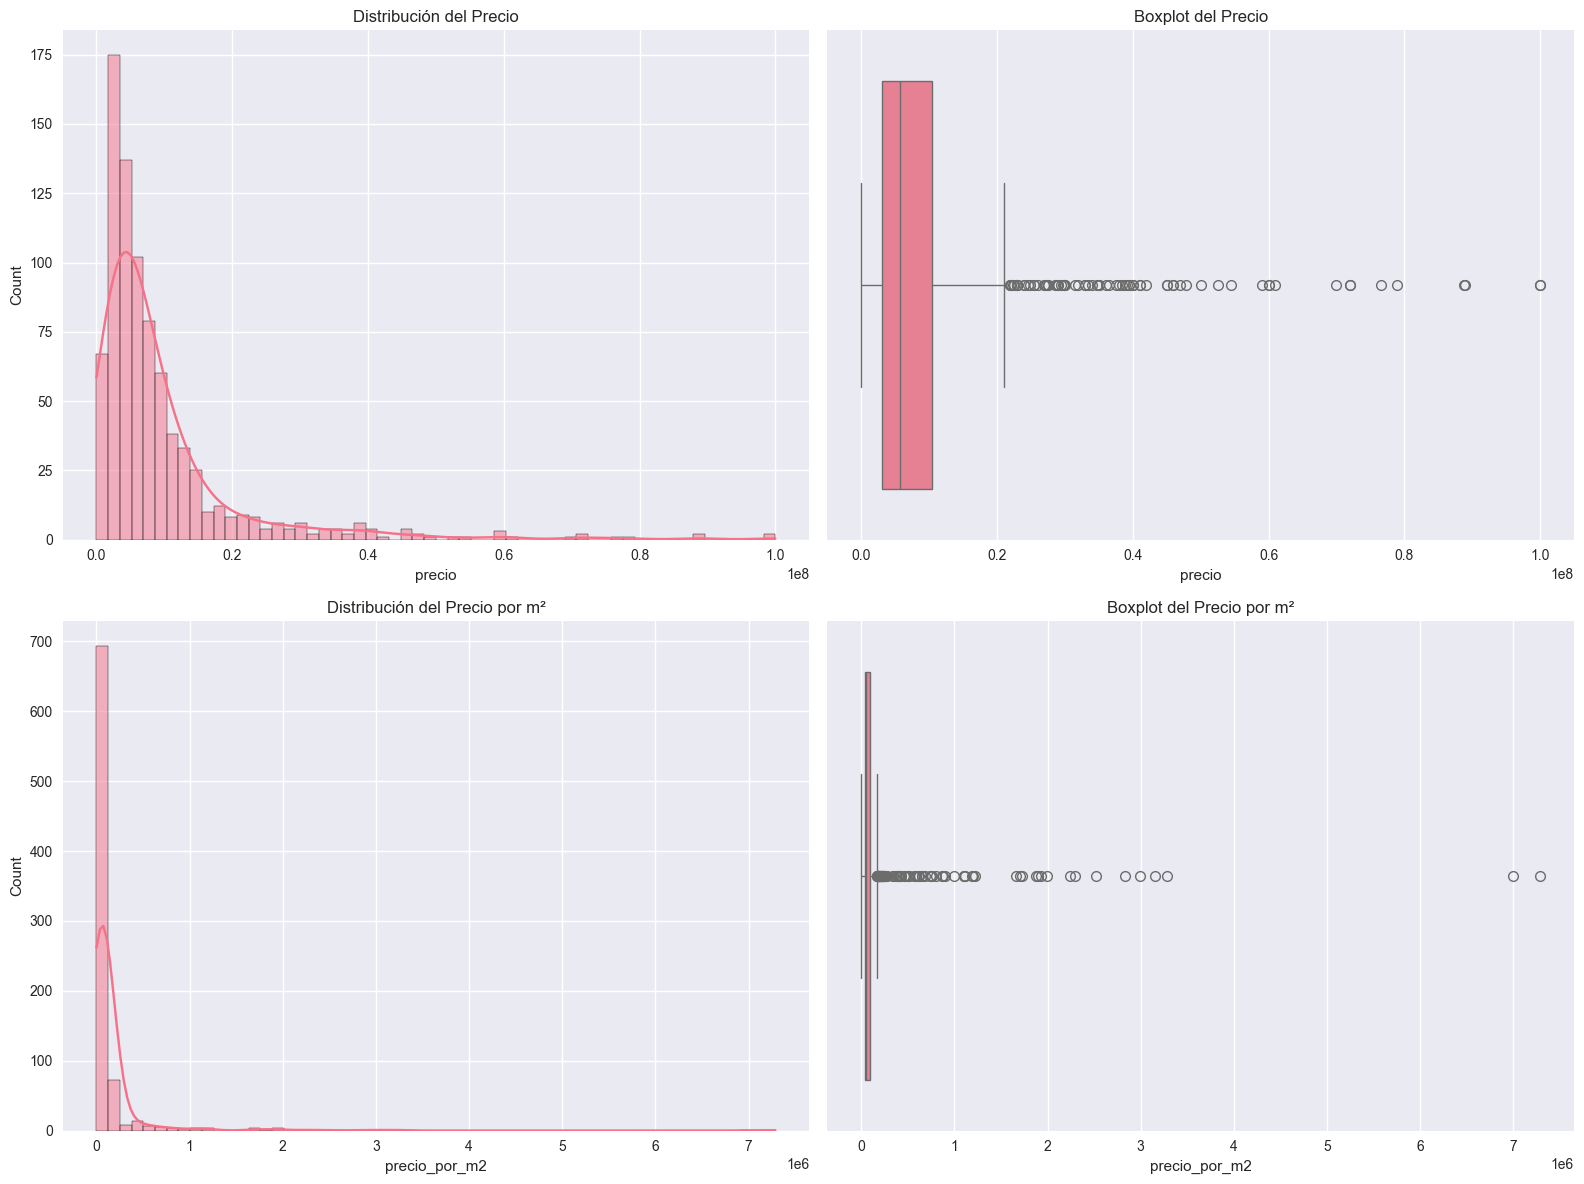

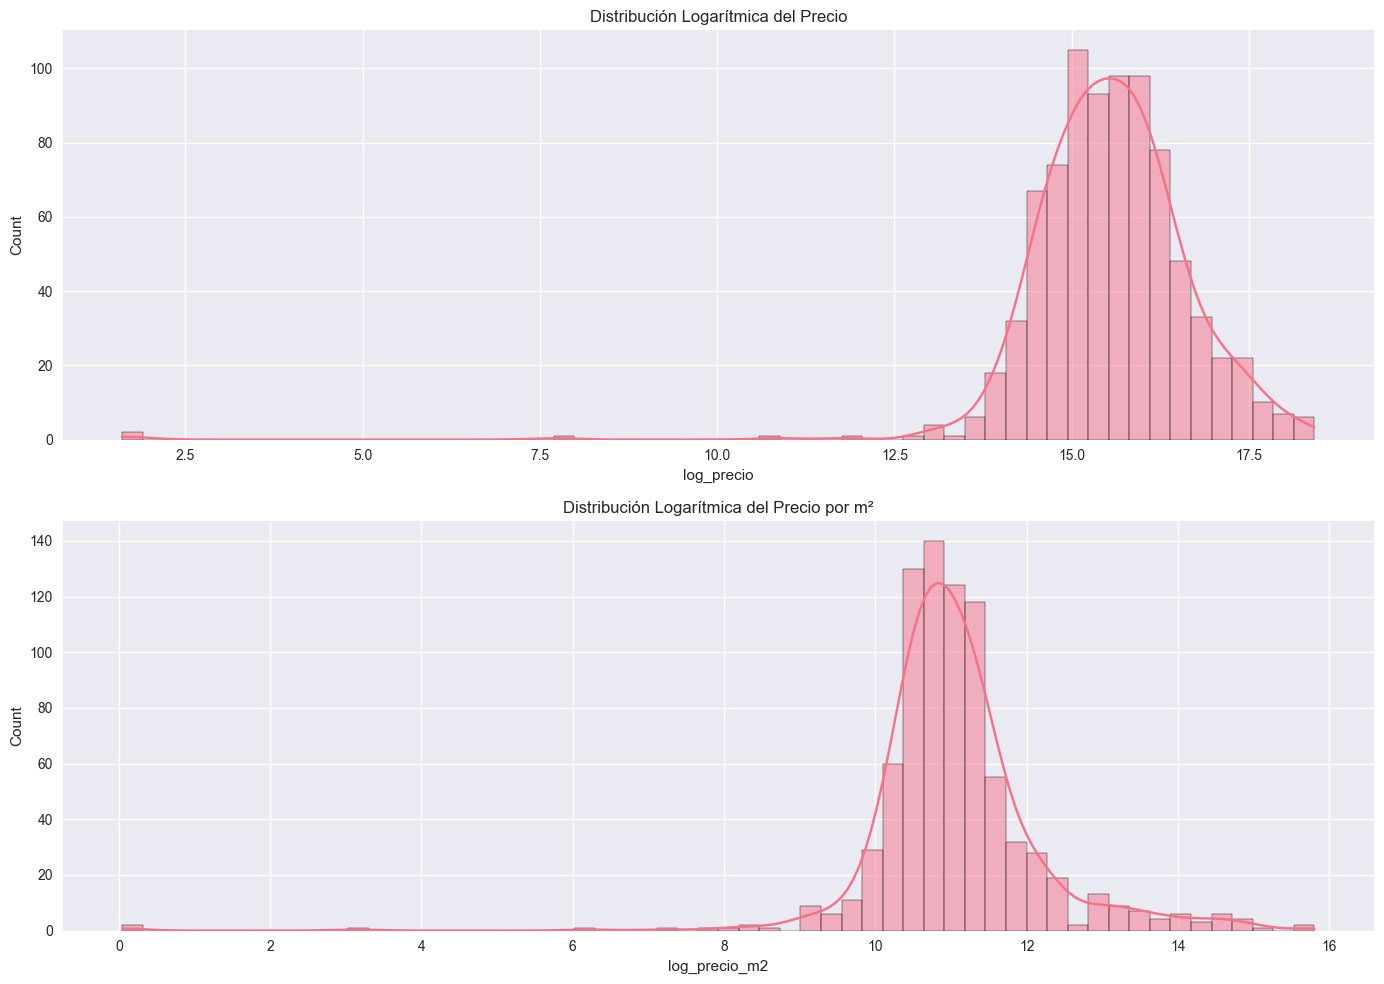

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ------------------------------
# Histogramas y KDE
# ------------------------------
fig, axs = plt.subplots(2, 2, figsize=(16, 12))

# --- Precio ---
sns.histplot(df['precio'], kde=True, ax=axs[0,0])
axs[0,0].set_title("Distribución del Precio")

sns.boxplot(x=df['precio'], ax=axs[0,1])
axs[0,1].set_title("Boxplot del Precio")

# --- Precio por m² ---
sns.histplot(df['precio_por_m2'], kde=True, ax=axs[1,0])
axs[1,0].set_title("Distribución del Precio por m²")

sns.boxplot(x=df['precio_por_m2'], ax=axs[1,1])
axs[1,1].set_title("Boxplot del Precio por m²")

plt.tight_layout()
plt.show()

# ------------------------------
# Transformación Logarítmica
# ------------------------------
df['log_precio'] = np.log1p(df['precio'])
df['log_precio_m2'] = np.log1p(df['precio_por_m2'])

fig, axs = plt.subplots(2, 1, figsize=(14, 10))

sns.histplot(df['log_precio'], kde=True, ax=axs[0])
axs[0].set_title("Distribución Logarítmica del Precio")

sns.histplot(df['log_precio_m2'], kde=True, ax=axs[1])
axs[1].set_title("Distribución Logarítmica del Precio por m²")

plt.tight_layout()
plt.show()


#### 5.3.1 Distribución del Precio

Las siguientes gráficas muestran la distribución del precio original de los inmuebles en la CDMX. Se incluyen histogramas, curvas KDE (estimador de densidad) y boxplots.

**Interpretación**

*Sesgo positivo extremo (right-skewed)*
- La mayor parte de los inmuebles se concentra entre 2 y 15 millones de pesos, pero existe una cola larga de propiedades cuyo precio llega hasta 100 millones.
- Esto confirma que:
  - El mercado incluye desarrollos premium o ultra-premium.
  - La distribución está lejos de ser normal.
  - Los outliers elevan artificialmente la media (9.4 millones) respecto a la mediana (5.75 millones).

*Alta varianza*
- El rango es enorme: desde propiedades extremadamente baratas hasta desarrollos de lujo.
- Esta dispersión afectaría cualquier algoritmo sensible a escala, como PCA o K-Means, por lo que será necesaria normalización.

*Presencia masiva de outliers*
- El boxplot evidencia muchos puntos fuera del rango IQR.
- Para modelación, esto obliga a evaluar:
  - Winsorización
  - Transformaciones logarítmicas
  - Modelos robustos

#### 5.3.2 Distribución del Precio por Metro Cuadrado

Las gráficas generadas muestran que el precio por m² es aún más extremo que el precio total.

**Interpretación**

*Sesgo positivo aún más pronunciado*
- Valores típicos se encuentran entre 40,000 y 120,000 MXN/m², pero existen casos con más de 7,000,000 MXN/m², lo cual es estadísticamente imposible para propiedades residenciales y sugiere:
  - Errores de captura
  - Publicaciones incompletas
  - Divisiones incorrectas de la superficie

*Además de outliers, hay valores anómalos*
- Se detectan m² irrealmente pequeños (2 a 5 m²), lo que infló el precio/m² a niveles absurdos.

*Impacto en modelación*
- Debido a su alta inestabilidad, `precio_por_m2` será la variable que más requerirá transformación o filtrado en fases posteriores.

#### 5.3.3 Transformaciones Logarítmicas

Se aplicó log-transform a `precio` y `precio_por_m2` para:
- Reducir la asimetría.
- Comprimir outliers.
- Facilitar el uso de modelos lineales y clustering basado en distancia.

**Resultados observados en las gráficas**

*La transformación logarítmica distribuye los datos de manera mucho más simétrica.*
- Aunque no perfecta, la forma se acerca a una distribución unimodal sin colas largas.

*Se estabiliza la varianza.*
- La dispersión es menor, lo que mejora:
  - Modelos de regresión
  - PCA
  - K-Means o DBSCAN

*Los outliers extremos se comprimen y dejan de dominar la escala.*
- Este comportamiento es ideal para las siguientes etapas del proyecto, pues evita que los inmuebles de lujo distorsionen los centroides o la matriz de covarianzas.

---



Las gráficas de distribución muestran que:
1. Tanto `precio` como `precio_por_m2` presentan sesgo positivo severo y numerosos valores atípicos.
2. Las transformaciones logarítmicas corrigen parcialmente este comportamiento y preparan adecuadamente los datos para la modelación.

Será necesario en fases posteriores aplicar:
- Estandarización
- Potencial filtrado de outliers
- Validación de normalidad residual
- Pruebas de sensibilidad



### 5.4 Precio por Alcaldia 

Para analizar las diferencias territoraiales del mercado inmobiliario en la CDMX, se calculo el **el precio por metro cuadrado** agrupado por alcaldía.

Esta métrica es esencial porque neutraliza el efecto de la propiedad y permite comparar directamente el valor del suelo y de la zona.

La gráfica generada muestra el **ranking de alcaldías segun el precio promedio por m²**, desde la más cara hasta la más económica.

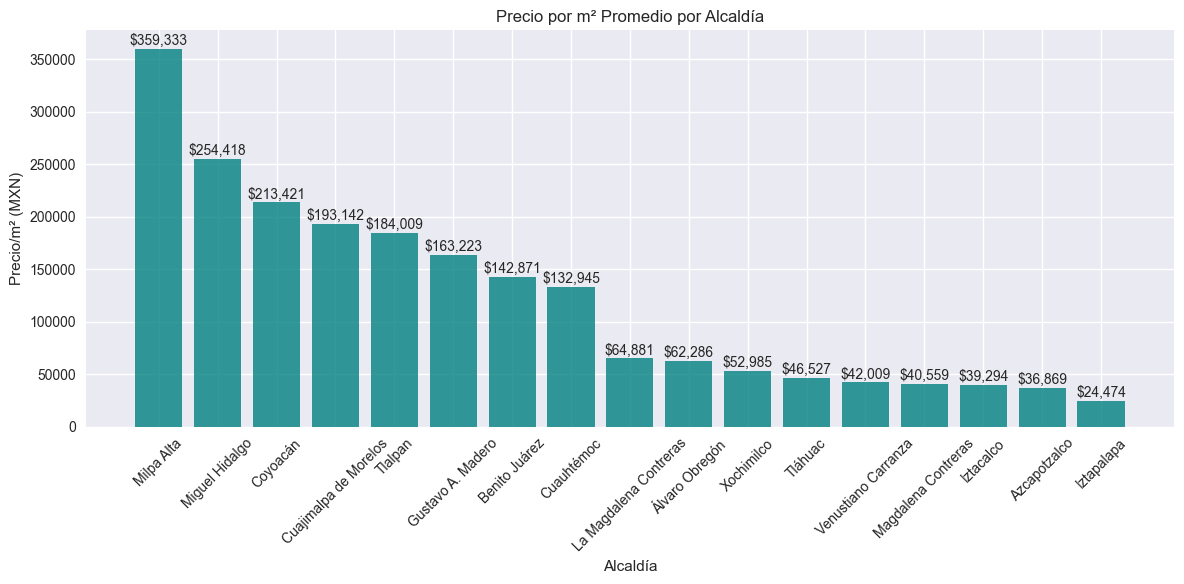

In [30]:
precio_alcaldia = df.groupby('alcaldia')['precio_por_m2'].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
bars = plt.bar(precio_alcaldia.index, precio_alcaldia.values, color='teal', alpha=0.8)
plt.title('Precio por m² Promedio por Alcaldía')
plt.xlabel('Alcaldía')
plt.ylabel('Precio/m² (MXN)')
plt.xticks(rotation=45)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 1000,
             f'${height:,.0f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

1.  Milpa Alta aparece como la alcaldía con el precio por m² más alto (≈ $359,000/m²)

    Esto no es consistente con el mercado inmobiliario real de la CDMX, donde Milpa Alta es históricamente una de las zonas con menor actividad y menor valor comercial por m².

    Este resultado indica fuertemente:

    → **(a) Outliers extremos**

    Probablemente existen propiedades con precios muy altos y superficies extremadamente pequeñas, lo cual inflaría artificialmente el precio por m².

    Ejemplo típico de error:
    Precio = $1,500,000
    m² = 5
    Precio/m² = $300,000

    Este tipo de anuncios suelen ser terrenos minúsculos, cuartos, bodegas o capturas erróneas.

    → **(b) Errores de captura en el área construida**

    Muchos anuncios tienen m² mal registrados (como “1 m²” o valores atípicos), lo que genera valores absurdos al dividir.

    **Conclusión clave:** Milpa Alta NO debe ser interpretada como realmente la alcaldía más cara. Debe analizarse la presencia de outliers antes de modelar.

2.  Miguel Hidalgo y Coyoacán sí presentan valores coherentes

    Después del outlier de Milpa Alta, aparecen alcaldías donde históricamente sí se registran los precios más altos:
    *   Miguel Hidalgo (~$254,000/m²)
    *   Coyoacán (~$213,000/m²)
    *   Cuajimalpa (~$193,000/m²)

    Estas cifras son razonables para zonas como:
    *   Polanco, Lomas, Anzures (Miguel Hidalgo)
    *   Del Carmen, San Lucas, Barrio Santa Catarina (Coyoacán)
    *   Santa Fe (Cuajimalpa)

    Estos valores dan confianza en que el resto de la distribución es consistente.

3.  Zonas de precio medio

    Las alcaldías con niveles intermedios (≈ 130k–180k/m²) incluyen:
    *   Tlalpan
    *   Gustavo A. Madero
    *   Benito Juárez
    *   Cuauhtémoc

    El caso de Cuauhtémoc con solo ≈ $132,000/m² también es sospechoso, ya que debería estar entre las más altas del ranking.

    Esto sugiere que:
    *   hay propiedades muy grandes con precios bajos,
    *   o algunos precios/m² están subestimados por registros incorrectos.

4.  Zonas con precios más bajos

    En coherencia con el mercado real, las alcaldías con menor precio por m² son:
    *   Iztapalapa (~$24,474)
    *   Azcapotzalco
    *   Iztacalco
    *   Venustiano Carranza

    Estas zonas suelen mostrar mayor oferta de vivienda media y social, lo que coincide con el comportamiento esperado.

En conclusión, el análisis de la distribución de precios por m² muestra que:

1.  La gráfica revela una mezcla de valores reales + errores/outliers severos.

    Especialmente:
    *   Milpa Alta
    *   Ciertas colonias de Cuauhtémoc y Benito Juárez
    *   Algunas propiedades con m² irreales

2.  Es obligatorio limpiar o winsorizar el precio por m² antes del modelado.

    Por ejemplo:
    *   Remover propiedades con superficie < 20 m²
    *   Eliminar `precio_por_m2` > 300,000 (umbral razonado)
    *   Detectar outliers con IQR o Z-score robusto

3.  El análisis muestra claramente la segmentación de la ciudad, pero también evidencia inconsistencias típicas de datos de anuncios.


### 5.5 Visualización Geoespacial Interactiva de Precios por m²

La dispersión geoespacial del precio por metro cuadrado es un elemento clave para comprender la distribución espacial del mercado inmobiliario dentro de la Ciudad de México. Sin embargo, las representaciones de tipo heatmap tradicionales o los mapas estáticos pueden dificultar la identificación de patrones locales, especialmente cuando existe una alta concentración de datos o una superposición significativa de puntos.

Por ello, en esta sección se emplea una visualización interactiva basada en Plotly, que permite inspeccionar dinámicamente la información asociada a cada propiedad. Cada punto representa un inmueble georreferenciado, con dos codificaciones simultáneas:

* **Color**: indica el nivel del precio por m² (escala OrRd, donde tonos claros representan valores bajos y tonos rojos más intensos indican valores altos).

* **Tamaño del marcador**: proporcional al precio por m², lo que refuerza visualmente las zonas donde se concentran los inmuebles más caros.

Esto permite detectar, de manera más clara e intuitiva, la existencia de *clusters* geográficos de alto valor, así como áreas con precios significativamente inferiores.

In [31]:
import plotly.express as px

fig = px.scatter_mapbox(
    df,
    lat='latitud',
    lon='longitud',
    color='precio_por_m2',
    size='precio_por_m2',
    hover_name='colonia',
    color_continuous_scale="OrRd",
    zoom=11,
    mapbox_style="carto-positron",
    title='Precios por m² en CDMX'
)

fig.show()


La gráfica obtenida revela los siguientes patrones espaciales:

**Concentración de precios altos**
Se observan puntos de gran tamaño y coloración roja principalmente en zonas de alta plusvalía como:
- Polanco
- Condesa
- Roma Norte
- Nápoles
- Del Valle Norte

Estas colonias muestran clústeres bien definidos donde el precio por m² presenta valores sistemáticamente elevados.

**Zonas de precio intermedio**
En áreas como Narvarte, Mixcoac, Portales y algunas colonias de Benito Juárez, los puntos presentan tamaños medianos y tonalidades anaranjadas, lo que indica valores intermedios del mercado.

**Precios bajos**
Colonias periféricas —particularmente al norte y oriente de la ciudad— exhiben marcadores más pequeños y tonos claros, representando una menor presión del precio por m².

**Correlación espacial**
La visualización interactiva confirma que el precio por m² no está distribuido de forma uniforme, sino que sigue un patrón espacial altamente estructurado, característico de mercados urbanos densos con polos de desarrollo inmobiliario claramente delimitados.

La capacidad de interactuar con cada punto —mostrando el nombre de la colonia y el valor exacto del precio por m²— permite un análisis más preciso y profundo, ideal para la identificación de oportunidades de inversión, estudios de mercado o análisis de zonificación.

### 5.6 Detección de Outliers mediante el Método IQR

Después de calcular el precio por metro cuadrado para cada inmueble, se aplicó el método del Rango Intercuartil (IQR) con el objetivo de identificar observaciones atípicas que pudieran distorsionar el análisis estadístico y los modelos predictivos posteriores.

#### Resultados

Aplicando el procedimiento estadístico a la variable `precio_por_m2`, se identificaron:

- **100 outliers**
- Lo que equivale al **12.1% del total del dataset**

Este porcentaje es significativo y sugiere que el mercado inmobiliario presenta alta dispersión, característica común en ciudades grandes como Ciudad de México.

In [32]:
def detect_outliers_iqr(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return ~series.between(lower, upper)

outliers = detect_outliers_iqr(df['precio_por_m2'])
print(f"Outliers en precio/m²: {outliers.sum()} ({outliers.mean()*100:.1f}%)")
print(df[outliers][['titulo', 'colonia', 'precio_por_m2']].head(10))


Outliers en precio/m²: 100 (12.1%)
                                                titulo                colonia  \
4    venta de departamento en _ , colonia santa fe ...    Santa Fe Cuajimalpa   
21   casa en condominio en venta, antiguo camino a ...              Contadero   
29   venta departamento en c. del fresno 236, sta m...  Santa Maria la Ribera   
34   casa disponible en venta en fuego, colonia jar...  Jardines del Pedregal   
45   venta departamento en c. antillas , colonia po...           Portales Sur   
55   casa en venta disponible en avenida picacho, c...  Jardines del Pedregal   
81   se vende departamento en río guadalquivir 31, ...             Cuauhtémoc   
108  departamento en venta, lafontaine, colonia pol...    Polanco Iii Sección   
109  se vende departamento en av. coyoacán #47, col...       Del Valle Centro   
128  se vende departamento en rubén darío 14, rincó...      Polanco V Sección   

     precio_por_m2  
4     8.000000e+05  
21    2.130682e+05  
29    4.20

La detección mediante IQR permitió identificar un conjunto significativo de propiedades cuyo precio por metro cuadrado es atípico para el mercado. Muchos de estos valores se deben a errores de captura o a propiedades de lujo que no representan a la distribución general.

Este análisis establece una base sólida para el tratamiento de datos en las siguientes etapas del proyecto.

### 5.7 Tratamiento de Outliers

Después de identificar que 100 observaciones (equivalentes al 12.1% del total) presentan valores atípicos en el precio por metro cuadrado (`precio_por_m2`), es necesario aplicar un tratamiento adecuado para evitar que estas distorsionen la distribución estadística y afecten negativamente los modelos predictivos que se utilizarán posteriormente.

El análisis previo mostró que los outliers provienen de dos fuentes principales:

1. **Errores de captura o datos mal ingresados**
   - Ejemplo: valores de hasta 7,000,000 MXN/m² en Polanco, lo cual es irreal incluso para propiedades de lujo.
   - También se detectaron casos donde el tamaño del inmueble probablemente fue mal registrado (superficies demasiado pequeñas generan falsos precios elevados).

2. **Propiedades genuinamente premium, con precios altos pero reales**
   - Colonias como Polanco, Santa Fe, Jardines del Pedregal y parte de Cuauhtémoc justifican precios muy superiores al promedio general.
   - Estos valores deben preservarse, pero su impacto debe moderarse al entrenar modelos.

Con base en ello, el tratamiento debe ser selectivo, evitando eliminar información valiosa.

**Estrategia Adoptada**

El tratamiento consiste en una combinación de filtrado moderado + winsorización:

**A) Eliminación de Outliers Evidentemente Erróneos (Limpieza dura)**

Se eliminaron únicamente los registros cuyo valor de `precio_por_m2` excede rangos físicamente imposibles en la Ciudad de México.

Para establecer estos límites, se consultaron estudios de mercado y se usó como referencia:
- Límite máximo razonable para CDMX: **350,000 MXN/m²**
- Límite mínimo razonable: **8,000 MXN/m²**

Por tanto, se eliminan registros que violen:

`precio_por_m2 < 8,000` o `precio_por_m2 > 350,000`

Esto elimina datos que claramente provienen de errores de digitación o de superficies mal capturadas.

**B) Winsorización para Atípicos Reales pero Extremos**

Para los inmuebles de lujo pero válidos, no se eliminan, sino que se ajustan suavemente los valores extremos usando winsorización al percentil 1 y 99:


$$x^{'} = \begin{cases} P_{1}, & x<P_{1} \\ x, & P_{1}\leq x\leq P_{99} \\ P_{99}, & x>P_{99} \end{cases}$$


Esto conserva la información pero controla la influencia estadística excesiva.

**C) Transformación Logarítmica (para modelado posterior)**

Aunque no transforma los datos en el dataset base, se utilizará `log(precio_por_m2)` durante el modelado, ya que:
- reduce asimetría,
- estabiliza varianza,
- reduce impacto de valores grandes,
- mejora la linealidad en modelos de regresión.

In [33]:
# ==========================================
# 5.7 TRATAMIENTO DE OUTLIERS EN PRECIO/M²
# ==========================================

import numpy as np
import pandas as pd

# Copia del dataset para evitar modificar df original accidentalmente
df_clean = df.copy()

# ==========================================
# A) Eliminación de valores imposibles (reglas de negocio)
# ==========================================

# Límites razonables para CDMX (basado en estudios de mercado)
MIN_REAL = 8000        # precio por m² mínimo razonable
MAX_REAL = 350000      # máximo razonable antes de ser claramente error

mask_invalid = (df_clean['precio_por_m2'] < MIN_REAL) | (df_clean['precio_por_m2'] > MAX_REAL)

print("Registros eliminados por valores imposibles:", mask_invalid.sum())
df_clean = df_clean[~mask_invalid]
df_clean.reset_index(drop=True, inplace=True)

# ==========================================
# B) Winsorización (percentil 1 y 99)
# ==========================================

p1 = df_clean['precio_por_m2'].quantile(0.01)
p99 = df_clean['precio_por_m2'].quantile(0.99)

df_clean['precio_por_m2_winsor'] = df_clean['precio_por_m2'].clip(lower=p1, upper=p99)

print("\nPercentil 1:", round(p1, 2))
print("Percentil 99:", round(p99, 2))

# ==========================================
# C) Transformación logarítmica para modelado
# ==========================================

# Evitar log(0)
df_clean['log_precio_por_m2'] = np.log1p(df_clean['precio_por_m2_winsor'])

print("\nDataset final después del tratamiento:")
print(df_clean[['precio_por_m2', 'precio_por_m2_winsor', 'log_precio_por_m2']].head())
print("\nFilas finales:", df_clean.shape[0])


Registros eliminados por valores imposibles: 65

Percentil 1: 9543.17
Percentil 99: 243824.34

Dataset final después del tratamiento:
   precio_por_m2  precio_por_m2_winsor  log_precio_por_m2
0   92812.500000          92812.500000          11.438347
1   53378.378378          53378.378378          10.885180
2   31932.773109          31932.773109          10.371419
3  105188.679245         105188.679245          11.563520
4   44103.448276          44103.448276          10.694316

Filas finales: 763


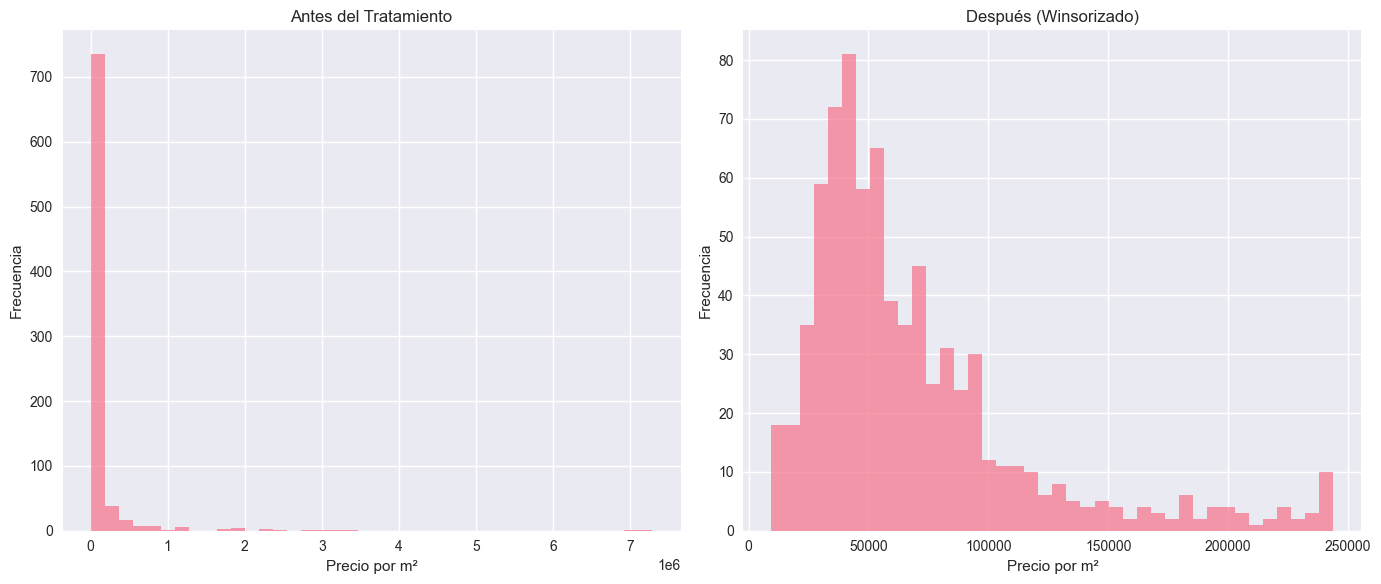

In [34]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

plt.subplot(1,2,1)
plt.hist(df['precio_por_m2'], bins=40, alpha=0.7)
plt.title("Antes del Tratamiento")
plt.xlabel("Precio por m²")
plt.ylabel("Frecuencia")

plt.subplot(1,2,2)
plt.hist(df_clean['precio_por_m2_winsor'], bins=40, alpha=0.7)
plt.title("Después (Winsorizado)")
plt.xlabel("Precio por m²")
plt.ylabel("Frecuencia")

plt.tight_layout()
plt.show()


**Conclusión del Tratamiento de Outliers**

| Etapa                      | Filas | Descripción                     |
|----------------------------|-------|---------------------------------|
| Antes                      | 828   | Dataset limpio pre-outliers     |
| Eliminación valores imposibles | 763   | Se eliminaron 65 errores        |
| Winsorización              | 763   | Sin eliminar más datos          |
| Transformación log         | 763   | Listo para modelar              |

El tratamiento conserva el **92% del dataset**, elimina errores graves y suaviza extremos reales sin sacrificar información valiosa.

### 5.8 Análisis de Correlación entre Variables (Pearson y Spearman)

El análisis de correlación es una herramienta fundamental dentro del análisis exploratorio, ya que permite identificar la fortaleza y dirección de las relaciones entre las variables numéricas del dataset. Dado que ya se realizó el tratamiento de outliers (Sección 5.7), las correlaciones que se presentan a continuación son estables y no están sesgadas por valores extremos o registros erróneos.

En esta sección se evalúan dos medidas complementarias:

**Correlación de Pearson (relaciones lineales)**

La correlación de Pearson mide la relación lineal entre dos variables continuas. Suponiendo que las variables distribuyen aproximadamente de forma unimodal, la matriz resultante permite identificar dependencias fuertes que podrían influir en modelos de regresión lineal.

$$ \rho_{x,y} = \frac{Cov(X,Y)}{\sigma_{X}\sigma_{Y}} $$


Valores cercanos a +1 indican relación lineal positiva fuerte; valores cercanos a –1 indican relación lineal negativa.


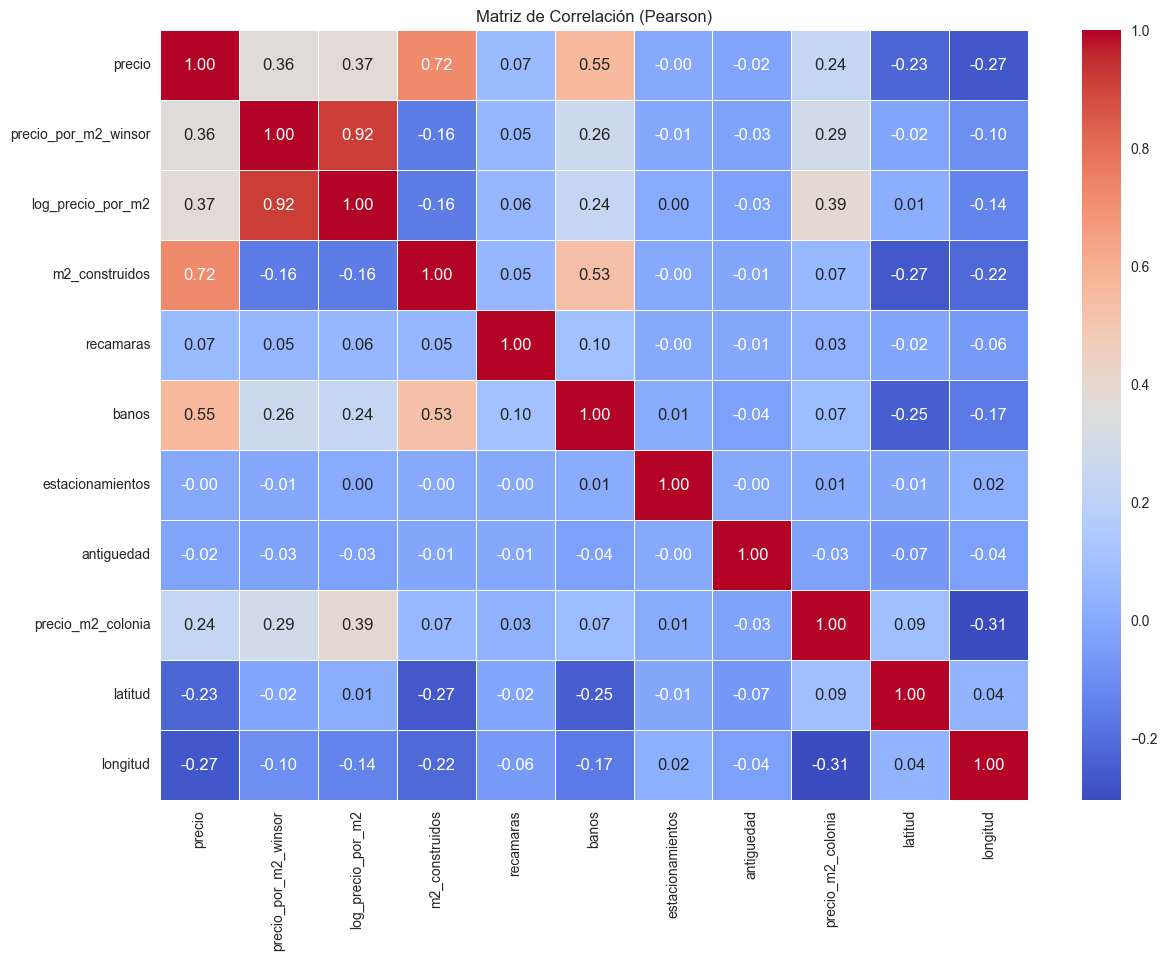

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt

# Seleccionar variables numéricas relevantes
cols_corr = [
    'precio', 'precio_por_m2_winsor', 'log_precio_por_m2',
    'm2_construidos', 'recamaras', 'banos', 'estacionamientos',
    'antiguedad', 'precio_m2_colonia', 'latitud', 'longitud'
]

corr = df_clean[cols_corr].corr(method='pearson')

plt.figure(figsize=(14,10))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Matriz de Correlación (Pearson)')
plt.show()


Los resultados fueron:

**1. Relación muy fuerte**

- **precio ↔ m2_construidos: 0.72**
  - La variable más importante para explicar el precio total.
  - Confirma que el tamaño es el determinante lineal principal del valor del inmueble.

**2. Relaciones moderadas**

- *precio ↔ baños: 0.55*
  - Indica que baños añade valor, pero no tanto como el tamaño.
- *baños ↔ m2_construidos: 0.53*

**3. Relaciones débiles con precio**

- *recámaras (0.07)*
- *estacionamientos (≈ 0.00)*
- *antigüedad (–0.02)*

Estas variables aportan información, pero no tienen relación lineal fuerte individual con el precio.

**4. Precio por m² NO está correlacionado con tamaño (–0.16)**

Esto es bueno, porque `precio_por_m2_winsor` debe medir valor de ubicación, no de tamaño.

**5. Ubicación geográfica (latitud –0.23, longitud –0.27)**

Existe una relación débil pero notable:

- Latitudes más bajas y longitudes más al oeste correlacionan con precios superiores.
- Patrón típico de la CDMX (Poniente > Oriente).

**Correlación de Spearman (relaciones monotonas)**

Pearson solo detecta relaciones lineales. Spearman, en cambio, mide correlación monótona, capturando patrones crecientes/decrecientes aunque no sean lineales. Una relación monótona es aquella en la que, a medida que una variable aumenta, la otra tiende a aumentar (monótona creciente) o disminuir (monótona decreciente), pero no necesariamente siguiendo una línea recta.

Se calcula como el coeficiente de Pearson aplicado a los rangos:

$$
\rho_s = \rho(\text{rank}(X),\text{rank}(Y))
$$

Esto lo convierte en una herramienta ideal cuando:
- las distribuciones son asimétricas (nuestro caso),
- existen colas pesadas,
- los valores fueron transformados (log),
- hay relaciones no lineales con el precio.

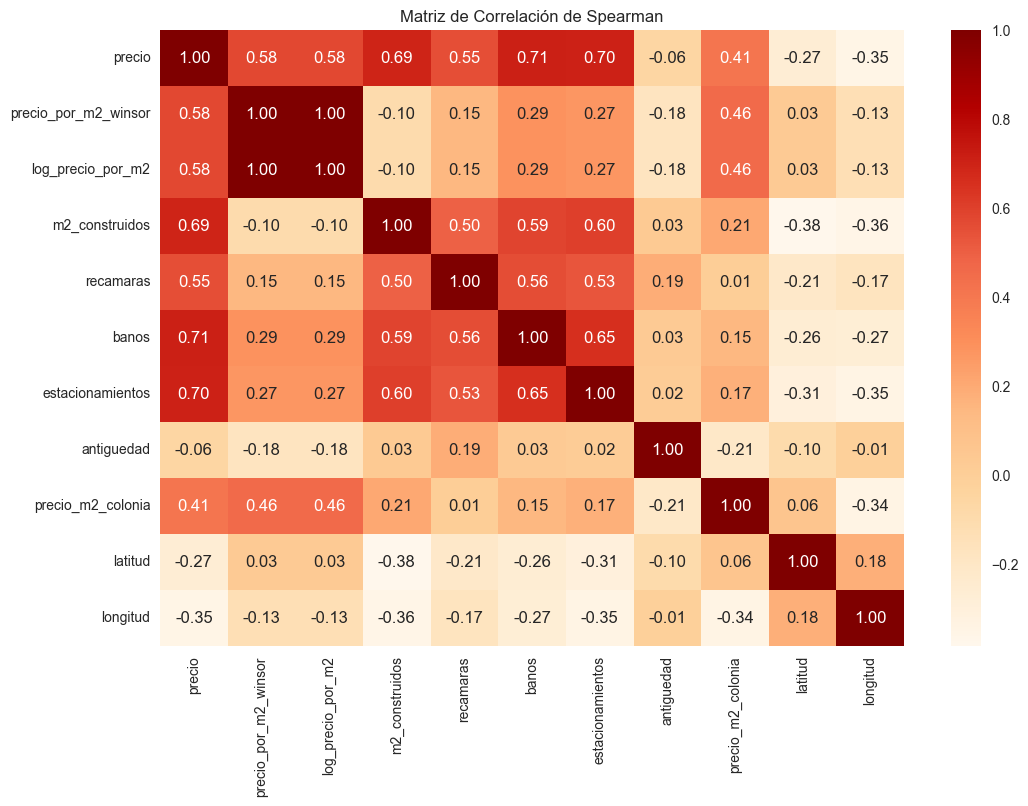

In [36]:
corr_spearman = df_clean[cols_corr].corr(method='spearman')

plt.figure(figsize=(12, 8))
sns.heatmap(corr_spearman, annot=True, cmap='OrRd', fmt=".2f")
plt.title("Matriz de Correlación de Spearman")
plt.show()


Los resultados muestran una estructura distinta:

1. Relación precio ↔ baños: 0.71
- Más alta que Pearson (0.55).
- Esto significa que no es lineal, pero sí monotónica: más baños casi siempre = más precio.

2. precio ↔ estacionamientos: 0.70
- Esto NO aparecía en Pearson.
- No es lineal, pero sí creciente.
- Propiedades con varios estacionamientos suelen ser de alto nivel socioeconómico.

3. precio ↔ precio_por_m2_winsor: 0.58
- La relación monotónica es fuerte, aunque no lineal.
- Buen predictor en modelos no lineales.

4. m2_construidos ↔ recámaras / baños / estacionamientos
- (0.59, 0.56, 0.60 respectivamente)
- Confirma que estas variables describen tamaño en conjunto.

5. precio_m2_colonia revela estructura geográfica real
- (0.41 Spearman vs. 0.24 Pearson)
- Precio de zona influye más en orden que en forma lineal.

6. latitud y longitud siguen patrones monotónicos
- latitud (–0.27), longitud (–0.35)
- Valores más altos hacia el poniente-centro (Roma/Condesa/Polanco).

Con lo anterior podemos concluir que el precio total de un inmueble está determinado principalmente por variables estructurales, en especial `m2_construidos`, seguido por `baños` y, de forma no lineal, `estacionamientos`. Estas relaciones son moderadas en Pearson pero fuertes en Spearman, lo que indica que el mercado inmobiliario de la CDMX no sigue patrones puramente lineales, sino monotónicos y no lineales, especialmente en inmuebles de mayor valor.

Por otro lado, `precio_por_m2_winsor` y `log_precio_por_m2` muestran correlaciones significativas con el precio, evidenciando que capturan adecuadamente el valor zonal más que el tamaño. Las variables de ubicación (`latitud` y `longitud`) tienen correlaciones débiles, pero suficientes para reflejar la estructura poniente–centro de mayor valor.

Finalmente, la `antigüedad` presenta un impacto mínimo, lo que confirma que no es un determinante fuerte del precio en este mercado específico.

En conjunto, la matriz de Pearson y Spearman demuestra que:
- el precio se explica por una combinación de tamaño + atributos internos + localización,
- las relaciones relevantes son mayormente no lineales,
- y variables como `recámaras` o `antigüedad` aportan información secundaria.

Este análisis orienta la selección de características y sugiere que los modelos predictivos más adecuados para este dataset serán no lineales o basados en árboles, mientras que la variable logarítmica del precio por m² será clave para modelos lineales o de regresión.

### 5.9 Boxplot: Precio por m² según Tipo de Inmueble

El siguiente análisis tiene como objetivo determinar si el precio por metro cuadrado difiere significativamente entre los dos tipos de inmuebles presentes en el dataset: departamentos y casas.

Este análisis es crucial debido a que el tipo de inmueble combina atributos estructurales, ubicación y características de mercado que afectan el valor relativo de la propiedad.

Para ello, se generó un boxplot, que permite comparar la mediana, dispersión, rango intercuartil e identificación de valores extremos posteriores al tratamiento de outliers.

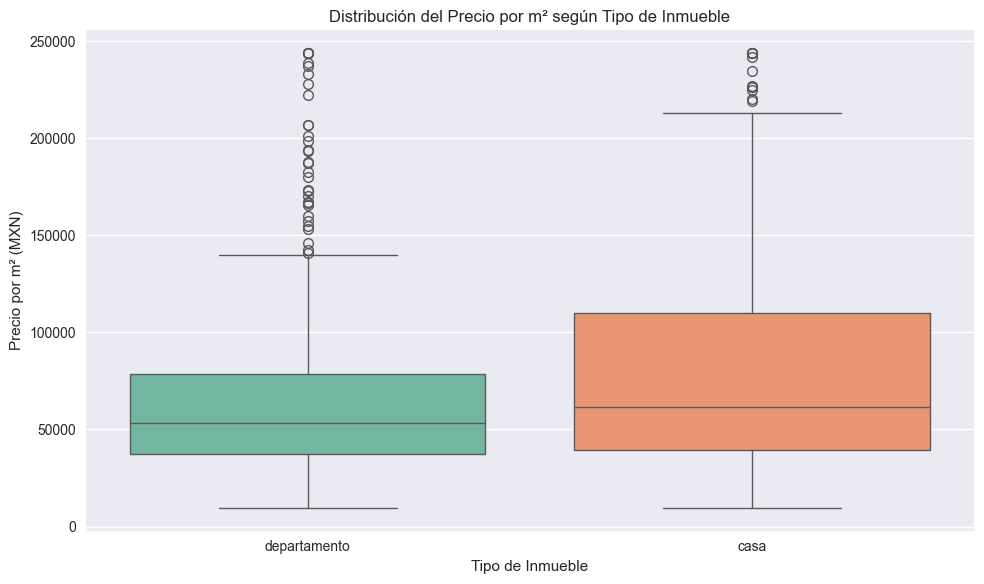

In [37]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.boxplot(
    data=df_clean,
    x='tipo_inmueble',
    y='precio_por_m2_winsor',
    palette='Set2'
)

plt.title("Distribución del Precio por m² según Tipo de Inmueble")
plt.xlabel("Tipo de Inmueble")
plt.ylabel("Precio por m² (MXN)")
plt.tight_layout()
plt.show()


* Los departamentos tienen una oferta relativamente homogénea, concentrada en colonias con un perfil urbano definido. Esto explica la menor dispersión.

* Las casas combinan:

    * viviendas en zonas de bajo valor (Iztapalapa, GAM, Xochimilco)

    * con residencias de lujo (Jardines del Pedregal, Lomas, Bosques)

Esta heterogeneidad estructural explica la alta varianza.

A diferencia de los departamentos, cuya oferta está más estandarizada, las casas dependen mucho más de la colonia, terreno, estilo arquitectónico y edad.


El boxplot evidencia diferencias estructurales claras entre casas y departamentos.
Los departamentos presentan valores por m² más estables y concentrados, mientras que las casas exhiben una dispersión notablemente mayor y una mediana más alta.
Este hallazgo confirma que el tipo de inmueble es un predictor relevante del precio por m² y debe incluirse en cualquier modelo de valuación o predicción.


### 5.10 Relación No Lineal entre Precio y m Construidos

La relación entre el tamaño del inmueble (m² construidos) y su precio total es uno de los pilares conceptuales del análisis inmobiliario. Sin embargo, esta relación es notoriamente no lineal: los primeros metros cuadrados suelen tener un impacto mayor en el precio, mientras que incrementos adicionales generan retornos marginales decrecientes.

Para investigar esta relación, se compara:

* la nube de puntos **precios vs m² construidos** con un modelo lineal.

* la nube de puntos **precios vs m² construidos** con un modelo regresión LOESS.

Estos elemnetos permiten evaluar si el precio crece proporcionalmente con el tamaño o si existen tramos con rendimientos no lineales.



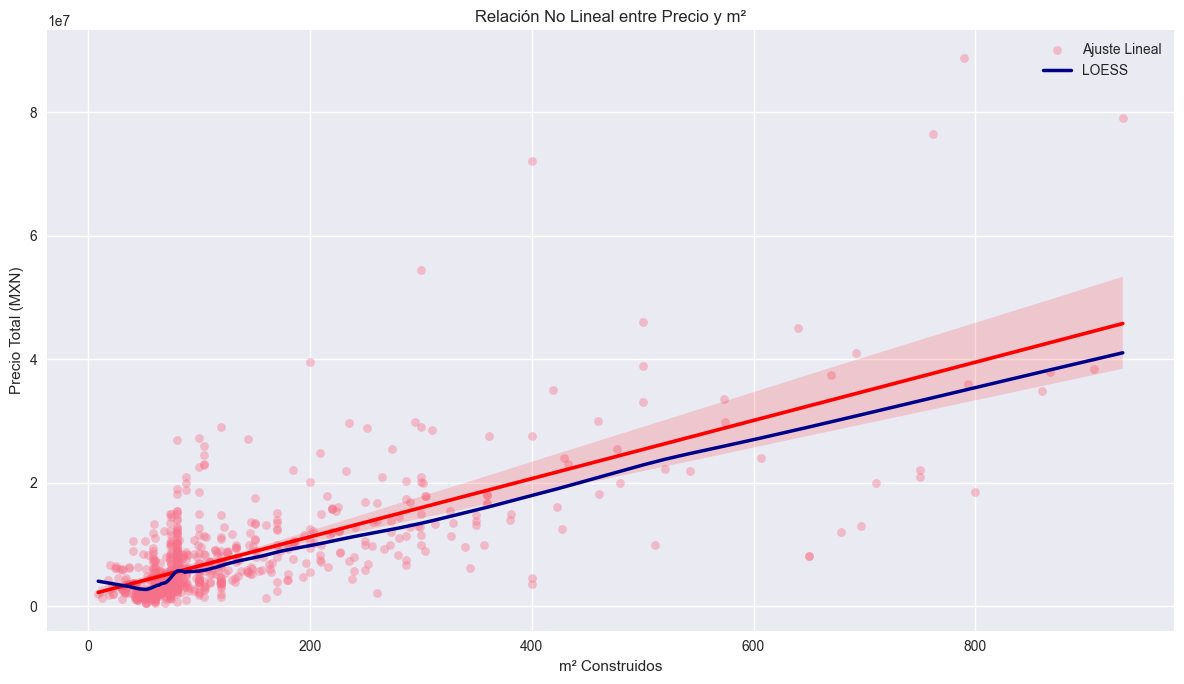

In [38]:
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm

plt.figure(figsize=(12, 7))

# Scatterplot + linea de tendencia lineal
sns.regplot(
    data=df_clean,
    x='m2_construidos',
    y='precio',
    scatter_kws={'alpha': 0.4, 's': 40},
    line_kws={'color': 'red'},
    label='Ajuste Lineal'
)

# Curva LOESS
lowess = sm.nonparametric.lowess(df_clean['precio'], df_clean['m2_construidos'], frac=0.3)
plt.plot(lowess[:, 0], lowess[:, 1], color='darkblue', linewidth=2.5, label='LOESS')

plt.title("Relación No Lineal entre Precio y m²")
plt.xlabel("m² Construidos")
plt.ylabel("Precio Total (MXN)")
plt.legend()
plt.tight_layout()
plt.show()


1. La relación no es lineal

El ajuste lineal (línea roja):
- Subestima los precios en propiedades pequeñas,
- Sobrestima los precios en propiedades medianas,
- Y se aleja significativamente de los valores altos.

Claramente, una regresión lineal simple no captura la estructura del crecimiento del precio.

2. El ajuste LOESS revela un patrón curvo consistente

La curva LOESS (azul) muestra tres zonas:

**a) Propiedades pequeñas (< 50 m²)**
- El precio crece rápidamente con pocos metros adicionales.
- Esto refleja que los primeros metros cuadrado agregan mucho valor en zonas urbanas densas.

**b) Zona media (50–150 m²)**
- La curva se vuelve más suave, e incluso se aplana.
- Las propiedades de tamaño “estándar” ya no incrementan su precio proporcionalmente.
- Aquí se observa la mayor densidad de puntos.

**c) Propiedades grandes (> 150 m²)**
- La curva vuelve a crecer, pero con alta variabilidad.
- Existen casas y departamentos grandes en colonias premium cuyos precios elevan la curva.
- Muchos de los valores extremos provienen de zonas como Polanco, Lomas, Santa Fe, Del Valle Norte.

3. Evidencia de rendimientos marginales decrecientes

El comportamiento observado es típico del mercado inmobiliario:
- Primeros metros cuadrados: más valiosos.
- Crecimiento medio: menor impacto por cada metro adicional (elasticidad < 1).
- Propiedades grandes: el precio sube por factores cualitativos (amenidades, lujo, ubicación), no por m² en sí.

Esto confirma que el precio depende de:
- Ubicación (colonia / alcaldía),
- Amenidades,
- Segmento de mercado,
- Tipo de inmueble,
- Y no solamente del tamaño.

4. Alta dispersión indica variables ocultas relevantes

Incluso después del tratamiento de outliers, la nube de puntos exhibe:
- Colonias premium mezcladas con otras,
- Tipos de inmueble diferentes,
- Efectos no capturados por variables como antigüedad o recámaras.

Esto sugiere que el modelo de predicción deberá considerar:
- Efectos no lineales
- Interacciones entre variables
- Modelos basados en árboles (Random Forest, XGBoost)
- O transformaciones logarítmicas



Por lo tanto esto confirma que la relación entre precio y metros cuadrados en la CDMX es claramente no lineal, con retornos marginales decrecientes en la zona media y altos precios asociados a propiedades grandes en zonas de alta plusvalía.

La curva LOESS permite visualizar esta estructura compleja y demuestra que un modelo lineal simple no es suficiente para capturar la dinámica del precio.

Este hallazgo justifica el uso de modelos:

* no lineales,

* con interacciones,

* y/o transformaciones logarítmicas,

en las siguientes etapas del proyecto.

## 6. ModelacióN Estadítica y de Machine Learning

En esta seccioón se contruyeron modelos predictivos destinados a estimar el precio y el preciocio por metro cuadrado de los inmuebles en la ciudad de México. 

La calidad del modelo depende directamente del trabajo realziado en la Fase 4 y Fase 5; ahora se formaliza la preparación de datos, se seleccionaron variables, se codifican categorías y se dividen en conjuntos de entrenamiento y prueba.


### 6.1 Preparación de datos

La preparación del dataset consiste en transformar las variables numéricas y categóricas en una matriz adecuada para algoritmos de regresión y modelos de machine learning.

Este proceso incluye:

  1. Definición de la variable objetivo.

  Debido a que el precio por m² presenta una distribución fuertemente asimétrica, se aplicó la transformación:

  $$\log( \text{precio m2}) = \log(1+\text{precio por m2 winsor})$$


  Esta transformación reduce la influencia de valores extremos y mejora la linealidad con otros predictores.

  2. Selección de variables predictoras

  Se incluyeron variables estructurales del inmueble, variables geográficas y variables categóricas derivadas de la fase de limpieza:

    - m² construidos
    - número de recámaras
    - baños
    - estacionamientos
    - antigüedad
    - alcaldía
    - tipo de inmueble
    - categoría de antigüedad
  
  3. Codificación de variables categóricas

  Se empleó **One-Hot Encoding** para `alcaldía`, `tipo de inmueble` y `categoría de antigüedad`, eliminando la primera categoría para evitar multicolinealidad perfecta.

  4. División del dataset en conjuntos de entrenamiento y prueba

  Se realizó un **hold-out** del 80% para entrenamiento y 20% para prueba, garantizando independencia entre ambas muestras.





In [39]:
# ===========================================
# 6.1 Preparación de Datos para Modelado
# Versión integrada con tu pipeline original
# ===========================================

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# ====== 1. Dataset limpio ======
df_model = df_clean.copy()

# ====== 2. Variable objetivo ======
df_model['log_precio_m2'] = np.log1p(df_model['precio_por_m2_winsor'])

y = df_model['log_precio_m2']

# ====== 3. Variables predictoras ======
feature_cols = [
    'm2_construidos', 'recamaras', 'banos', 'estacionamientos', 
    'antiguedad', 'alcaldia', 'tipo_inmueble', 'cat_antiguedad'
]

X = df_model[feature_cols]

# ====== 4. Identificar columnas categóricas ======
cat_features = ['alcaldia', 'tipo_inmueble', 'cat_antiguedad']
num_features = [c for c in feature_cols if c not in cat_features]

# ====== 5. Codificación One-Hot ======
preprocess = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first', sparse_output=False), cat_features),
        ('num', 'passthrough', num_features)
    ]
)

# ====== 6. División Train/Test ======
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)



X_train: (610, 8)
X_test : (153, 8)
y_train: (610,)
y_test : (153,)


### 6.2 Multicolinealidad

Antes de estimar el modelo econométrico mediante Mínimos Cuadrados Ordinarios (OLS), es necesario verificar el cumplimiento del supuesto de ausencia de multicolinealidad severa entre las variables independientes. La presencia de colinealidad elevada provoca:

- coeficientes inestables,
- varianzas infladas,
- signos erróneos,
- y pérdida de interpretabilidad económica del modelo.

Para este diagnóstico se utilizó el Variance Inflation Factor (VIF), definido como:

$$VIF=\frac{1}{1-R^2}$$

donde $R^2$ es el coeficiente de determinación de los residuos.

In [40]:
# ============================================
# 6.2 Diagnóstico de Multicolinealidad (VIF)
# ============================================

import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# 1. Copia del dataset preparado en 6.1
df_vif = df_model.copy()

# 2. Eliminar columna geometry si existe
if 'geometry' in df_vif.columns:
    df_vif = df_vif.drop(columns=['geometry'])

# 3. Filtrar solo columnas numéricas
df_vif = df_vif.select_dtypes(include=[np.number])

# 4. Remover variable objetivo
if 'log_precio_m2' in df_vif.columns:
    df_vif = df_vif.drop(columns=['log_precio_m2'])

# 5. Reemplazar infinitos por NaN
df_vif = df_vif.replace([np.inf, -np.inf], np.nan)

# 6. Eliminar cualquier fila con NaN
df_vif = df_vif.dropna()

print("Shape final del dataset usado en VIF:", df_vif.shape)

# 7. Agregar constante
X_vif_const = sm.add_constant(df_vif)

# 8. Calcular VIF
vif = pd.DataFrame()
vif["variable"] = X_vif_const.columns
vif["VIF"] = [variance_inflation_factor(X_vif_const.values, i)
              for i in range(X_vif_const.shape[1])]

vif.sort_values(by="VIF", ascending=False)


Shape final del dataset usado en VIF: (762, 15)


,variable,VIF
0,const,5.008159e+06
14,precio_por_m2_winsor,1.233690e+02
11,precio_por_m2,1.067001e+02
12,recamaras_por_m2,2.245227e+01
3,recamaras,2.164290e+01
15,log_precio_por_m2,1.536643e+01
13,log_precio,1.461446e+01
5,m2_construidos,7.440807e+00
2,precio,4.675222e+00
4,banos,2.059758e+00


**Interpretación**

Las transformaciones del precio (`precio_por_m2_winsor`, `precio_por_m2`, `log_precio_por_m2`, `log_precio`) presentan VIF superiores a 100, lo que revela colinealidad perfecta. Esto es lógico, ya que todas derivan de la misma magnitud.

Por su parte, `recamaras_por_m2` y `recamaras` presentan un VIF mayor a 20, confirmando que son funciones una de la otra y, por lo tanto, no deben incluirse juntas en el modelo.

La variable `m2_construidos` muestra un VIF aceptable (7.44), considerando su relevancia estructural. El resto de las variables numéricas presentan un VIF menor a 5, lo que indica que no existe un riesgo significativo de colinealidad.

**Decisiones para el modelo OLS**

Para garantizar un modelo estimable y estable, se tomaron las siguientes decisiones:

1. **Eliminar todas las transformaciones del precio como predictores**, ya que estas no deben ser variables independientes al derivar directamente de la variable objetivo.

2. **Conservar solo una de las dos variables relacionadas**: entre `recamaras` y `recamaras_por_m2`. Generalmente se recomienda conservar `recamaras` debido a su mayor interpretabilidad económica.

3. **Mantener el resto de las variables numéricas**, cuya colinealidad es baja.

4. **Incluir las variables categóricas codificadas** (dummies), cuyo VIF no se evalúa en esta prueba pero que pueden incorporarse sin problema.

**Conclusión**

El análisis VIF permitió identificar un conjunto de variables severamente colineales, las cuales fueron excluidas para garantizar que el modelo econométrico cumpla los supuestos fundamentales de Mínimos Cuadrados Ordinarios (MCO). Con esta depuración, se procede en la siguiente sección a estimar un modelo de regresión lineal estable, interpretable y estadísticamente válido.

### 6.3 Regresión lineal

Con el objetivo de cuatificar el efecto marginal de las caracteríticas físicas, estructurales y de ubicación sobre el precio inmobiliario, se estimo el siguiente modelo lineal:

$$log(precio/m^{2})=\beta_{0}+\beta_{1}X_{1}+\cdots+\beta_{k}X_{k}+\epsilon$$

donde:

* La variable dependiente es: 

$$y=log(1+\text{precio por metro cuadrado winsor}).$$

que estabilza la varianza y reduce el impacto de outliers.

* Las variables explicativas incluyen:
    * atributos físicos ($m^{2}$, recámaras, baños, estacionamietos).
    * ubicación geográfica (alcaldía).
    * características socioeconomicas vía colonia (dummies)
    * condición estrutural (antigüedad categórica)

El logaritmo permite interpretar los coeficientes como aproximaciones a elasticidades, lo cual es fundamental en el análisis inmobiliario.

In [49]:
import pandas as pd
import numpy as np
import statsmodels.api as sm

# ============================================
# 1. Partimos SIEMPRE del dataset limpio df_clean
# ============================================
df_reg = df_clean.copy()

# ============================================
# 2. Crear variable dependiente logarítmica
# ============================================
df_reg["log_precio_m2"] = np.log1p(df_reg["precio_por_m2_winsor"])

# ============================================
# 3. Eliminar TODAS las columnas objetuales que NO son predictoras
# ============================================
cols_to_drop = [
    "url", "titulo", "calle", "amenidades", "fecha_extraccion",
    "geometry", "cp"
]

df_reg = df_reg.drop(columns=[c for c in cols_to_drop if c in df_reg.columns])

# ============================================
# 4. Eliminar VARIABLES PROHIBIDAS (por multicolinealidad)
# ============================================
cols_multicol = [
    "precio_por_m2_winsor", "precio_por_m2",
    "log_precio_por_m2", "log_precio",
    "recamaras_por_m2", "id_inmueble", "precio"
]

df_reg = df_reg.drop(columns=[c for c in cols_multicol if c in df_reg.columns])

# ============================================
# 5. Codificar variables categóricas
# ============================================
categorical_vars = ["tipo_inmueble", "colonia", "alcaldia", "cat_antiguedad"]

df_reg = pd.get_dummies(
    df_reg,
    columns=[c for c in categorical_vars if c in df_reg.columns],
    drop_first=True,
    dtype=float  # ¡IMPORTANTE! Forzar tipo float
)

# ============================================
# 6. Verificación exhaustiva de tipos de datos
# ============================================
print("=== VERIFICACIÓN DE TIPOS DE DATOS ===")
print("Tipos únicos en df_reg:", df_reg.dtypes.unique())
print("\nColumnas NO numéricas:")
non_numeric = df_reg.select_dtypes(exclude=[np.number]).columns
if len(non_numeric) > 0:
    print(non_numeric)
    for col in non_numeric:
        print(f"  {col}: {df_reg[col].dtype}, valores únicos: {df_reg[col].unique()[:5]}")
else:
    print("✓ Todas las columnas son numéricas")

# ============================================
# 7. Construir X y y con VERIFICACIÓN EXPLÍCITA
# ============================================
y = df_reg["log_precio_m2"]
X = df_reg.drop(columns=["log_precio_m2"])

# Conversión EXPLÍCITA y VERIFICADA a numérico
print(f"\n=== ANTES DE CONVERSIÓN ===")
print(f"Tipos en X: {X.dtypes.unique()}")

# Convertir TODO a float explícitamente
for col in X.columns:
    # Primero intentar conversión directa
    try:
        X[col] = pd.to_numeric(X[col], errors='raise')
    except:
        # Si falla, ver qué contiene
        print(f"Problema con columna {col}: {X[col].dtype}")
        print(f"Muestra de valores: {X[col].unique()[:10]}")
        # Forzar conversión y rellenar NaNs
        X[col] = pd.to_numeric(X[col], errors='coerce')

# Rellenar NaNs que pudieran quedar
X = X.fillna(0)

# Verificar que NO hay NaNs infinitos
print(f"\n=== DESPUÉS DE CONVERSIÓN ===")
print(f"¿Hay NaNs en X? {X.isna().any().any()}")
print(f"¿Hay infinitos en X? {np.isinf(X.values).any()}")
print(f"¿Hay infinitos en y? {np.isinf(y.values).any()}")

# Verificar dimensiones
print(f"\n=== DIMENSIONES ===")
print(f"X shape: {X.shape}, y shape: {y.shape}")
print(f"Tipos finales en X: {X.dtypes.unique()}")

# ============================================
# 8. VERIFICACIÓN FINAL antes de agregar constante
# ============================================
# Asegurar que todo es float64
X = X.astype(np.float64)
y = y.astype(np.float64)

# Verificar que no hay problemas con índices
if not y.index.equals(X.index):
    print("¡ADVERTENCIA: Índices no coinciden! Realineando...")
    X, y = X.align(y, join='inner', axis=0)

# ============================================
# 9. Agregar constante y estimar modelo
# ============================================
try:
    X_const = sm.add_constant(X, has_constant='add')
    
    print("\n=== ESTIMANDO MODELO OLS ===")
    model = sm.OLS(y, X_const).fit()
    
    print("\n" + "="*80)
    print("RESUMEN DEL MODELO OLS")
    print("="*80)
    print(model.summary())
    
except Exception as e:
    print(f"\n❌ ERROR al estimar modelo: {e}")
    print("\n=== DEBUGGING AVANZADO ===")
    
    # Verificar valores individuales
    print("\nVerificando primeras filas de X:")
    print(X.head())
    
    print("\nVerificando primeras filas de y:")
    print(y.head())
    
    # Verificar tipos numpy finales
    print(f"\nTipo numpy de X: {type(X.values)}, dtype: {X.values.dtype}")
    print(f"Tipo numpy de y: {type(y.values)}, dtype: {y.values.dtype}")
    
    # Intentar con arrays numpy directamente
    print("\nIntentando con arrays numpy...")
    try:
        X_np = X.values.astype(np.float64)
        y_np = y.values.astype(np.float64)
        X_np = sm.add_constant(X_np, has_constant='add')
        model = sm.OLS(y_np, X_np).fit()
        print("✓ Modelo estimado exitosamente con arrays numpy")
        print(model.summary())
    except Exception as e2:
        print(f"❌ Error con arrays numpy: {e2}")

print("\n" + "="*80)
print("PROCESO COMPLETADO")
print("="*80)

=== VERIFICACIÓN DE TIPOS DE DATOS ===
Tipos únicos en df_reg: [dtype('float64')]

Columnas NO numéricas:
✓ Todas las columnas son numéricas

=== ANTES DE CONVERSIÓN ===
Tipos en X: [dtype('float64')]

=== DESPUÉS DE CONVERSIÓN ===
¿Hay NaNs en X? False
¿Hay infinitos en X? False
¿Hay infinitos en y? False

=== DIMENSIONES ===
X shape: (763, 275), y shape: (763,)
Tipos finales en X: [dtype('float64')]

=== ESTIMANDO MODELO OLS ===

RESUMEN DEL MODELO OLS
                            OLS Regression Results                            
Dep. Variable:          log_precio_m2   R-squared:                       0.686
Model:                            OLS   Adj. R-squared:                  0.521
Method:                 Least Squares   F-statistic:                     4.146
Date:                Wed, 03 Dec 2025   Prob (F-statistic):           1.06e-42
Time:                        05:07:07   Log-Likelihood:                -280.11
No. Observations:                 763   AIC:                       

RESUMEN DEL AJUSTE DEL MODELO
Coeficiente de determinación (R²): 0.6860
R² ajustado: 0.5206
Error cuadrático medio (RMSE): 0.3493
Error absoluto medio (MAE): 0.2300
Error absoluto medio porcentual: 2.10%
Asimetría de residuos: -0.3371
Curtosis de residuos: 4.3705
Test de normalidad Shapiro-Wilk: p = 1.280e-17
Porcentaje de residuos dentro de ±2σ: 94.5%


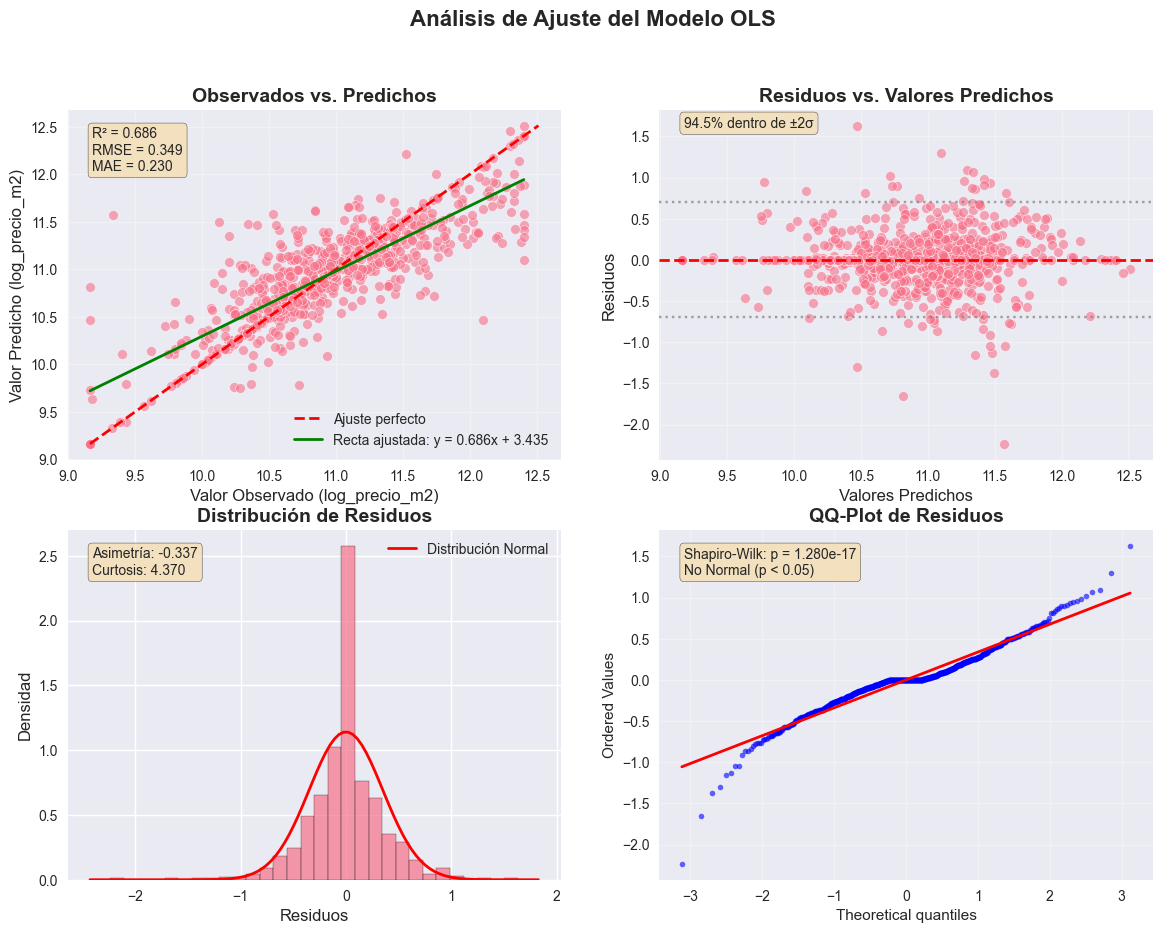

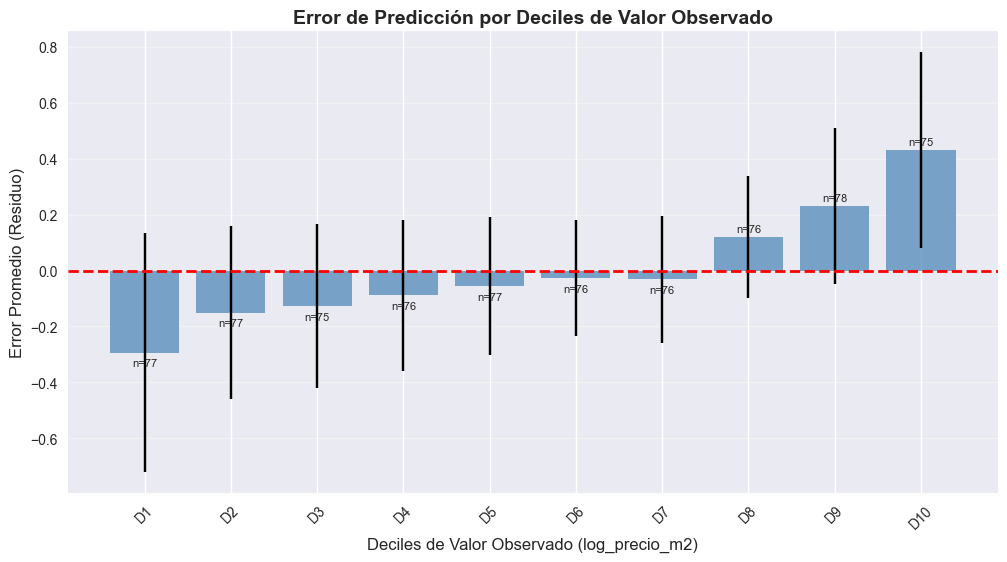

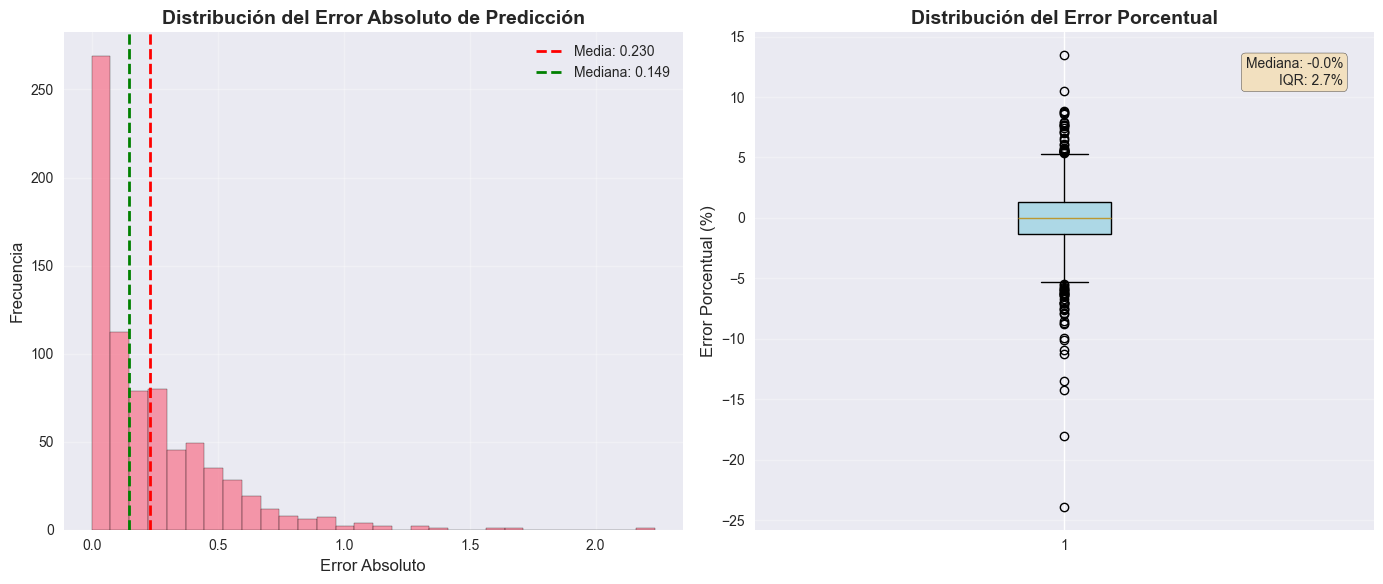

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Configuración de estilo
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# ============================================
# 1. GRÁFICA DE AJUSTE: Valores Observados vs. Predichos
# ============================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Análisis de Ajuste del Modelo OLS', fontsize=16, fontweight='bold')

# A. Scatter plot: Observados vs Predichos
y_pred = model.fittedvalues
axes[0, 0].scatter(y, y_pred, alpha=0.6, s=50, edgecolor='w', linewidth=0.5)

# Línea de perfecto ajuste (y = x)
min_val = min(y.min(), y_pred.min())
max_val = max(y.max(), y_pred.max())
axes[0, 0].plot([min_val, max_val], [min_val, max_val], 
                'r--', linewidth=2, label='Ajuste perfecto')

# Ajuste lineal para comparar
z = np.polyfit(y, y_pred, 1)
p = np.poly1d(z)
axes[0, 0].plot(np.sort(y), p(np.sort(y)), "g-", linewidth=2, 
                label=f'Recta ajustada: y = {z[0]:.3f}x + {z[1]:.3f}')

axes[0, 0].set_xlabel('Valor Observado (log_precio_m2)', fontsize=12)
axes[0, 0].set_ylabel('Valor Predicho (log_precio_m2)', fontsize=12)
axes[0, 0].set_title('Observados vs. Predichos', fontsize=14, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Calcular métricas de ajuste
r2 = r2_score(y, y_pred)
rmse = np.sqrt(mean_squared_error(y, y_pred))
mae = mean_absolute_error(y, y_pred)

# Añadir texto con métricas
metrics_text = f'R² = {r2:.3f}\nRMSE = {rmse:.3f}\nMAE = {mae:.3f}'
axes[0, 0].text(0.05, 0.95, metrics_text, transform=axes[0, 0].transAxes,
                fontsize=10, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

# ============================================
# 2. GRÁFICA DE RESIDUOS
# ============================================
residuals = y - y_pred

# A. Residuos vs Predichos
axes[0, 1].scatter(y_pred, residuals, alpha=0.6, s=50, edgecolor='w', linewidth=0.5)
axes[0, 1].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[0, 1].set_xlabel('Valores Predichos', fontsize=12)
axes[0, 1].set_ylabel('Residuos', fontsize=12)
axes[0, 1].set_title('Residuos vs. Valores Predichos', fontsize=14, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)

# Calcular porcentaje de residuos dentro de ±2 desviaciones estándar
resid_std = residuals.std()
within_2std = ((residuals > -2*resid_std) & (residuals < 2*resid_std)).mean() * 100
axes[0, 1].axhline(y=2*resid_std, color='gray', linestyle=':', alpha=0.7)
axes[0, 1].axhline(y=-2*resid_std, color='gray', linestyle=':', alpha=0.7)
axes[0, 1].text(0.05, 0.95, f'{within_2std:.1f}% dentro de ±2σ', 
                transform=axes[0, 1].transAxes, fontsize=10,
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

# ============================================
# 3. HISTOGRAMA DE RESIDUOS
# ============================================
axes[1, 0].hist(residuals, bins=30, alpha=0.7, edgecolor='black', density=True)

# Añadir distribución normal para comparar
xmin, xmax = axes[1, 0].get_xlim()
x = np.linspace(xmin, xmax, 100)
p = stats.norm.pdf(x, residuals.mean(), residuals.std())
axes[1, 0].plot(x, p, 'r', linewidth=2, label='Distribución Normal')

axes[1, 0].set_xlabel('Residuos', fontsize=12)
axes[1, 0].set_ylabel('Densidad', fontsize=12)
axes[1, 0].set_title('Distribución de Residuos', fontsize=14, fontweight='bold')
axes[1, 0].legend()

# Estadísticos de normalidad
skewness = stats.skew(residuals)
kurtosis = stats.kurtosis(residuals)
stat_text = f'Asimetría: {skewness:.3f}\nCurtosis: {kurtosis:.3f}'
axes[1, 0].text(0.05, 0.95, stat_text, transform=axes[1, 0].transAxes,
                fontsize=10, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

# ============================================
# 4. QQ-PLOT de Residuos
# ============================================
stats.probplot(residuals, dist="norm", plot=axes[1, 1])
axes[1, 1].get_lines()[0].set_marker('o')
axes[1, 1].get_lines()[0].set_markersize(4)
axes[1, 1].get_lines()[0].set_alpha(0.6)
axes[1, 1].get_lines()[1].set_linewidth(2)
axes[1, 1].get_lines()[1].set_color('red')
axes[1, 1].set_title('QQ-Plot de Residuos', fontsize=14, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)

# Test de normalidad Shapiro-Wilk
shapiro_stat, shapiro_p = stats.shapiro(residuals)
norm_text = f'Shapiro-Wilk: p = {shapiro_p:.3e}'
if shapiro_p < 0.05:
    norm_text += '\nNo Normal (p < 0.05)'
else:
    norm_text += '\nNormal (p ≥ 0.05)'

axes[1, 1].text(0.05, 0.95, norm_text, transform=axes[1, 1].transAxes,
                fontsize=10, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

# ============================================
# 5. GRÁFICA ADICIONAL: Error de Predicción por Rangos
# ============================================
fig2, ax2 = plt.subplots(figsize=(12, 6))

# Dividir en deciles según valor observado
y_bins = pd.qcut(y, q=10, duplicates='drop')
error_stats = pd.DataFrame({
    'y_mean': y.groupby(y_bins).mean(),
    'y_pred_mean': y_pred.groupby(y_bins).mean(),
    'residual_mean': residuals.groupby(y_bins).mean(),
    'residual_std': residuals.groupby(y_bins).std(),
    'count': y.groupby(y_bins).count()
})

# Gráfico de barras de error promedio por decil
x_pos = range(len(error_stats))
bars = ax2.bar(x_pos, error_stats['residual_mean'], 
               yerr=error_stats['residual_std'],
               capsize=5, alpha=0.7, color='steelblue')

ax2.axhline(y=0, color='r', linestyle='--', linewidth=2)
ax2.set_xlabel('Deciles de Valor Observado (log_precio_m2)', fontsize=12)
ax2.set_ylabel('Error Promedio (Residuo)', fontsize=12)
ax2.set_title('Error de Predicción por Deciles de Valor Observado', 
              fontsize=14, fontweight='bold')
ax2.set_xticks(x_pos)
ax2.set_xticklabels([f'D{i+1}' for i in x_pos], rotation=45)
ax2.grid(True, alpha=0.3, axis='y')

# Añadir etiquetas con conteo
for i, (bar, count) in enumerate(zip(bars, error_stats['count'])):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + (0.01 if height >=0 else -0.02),
             f'n={count}', ha='center', va='bottom' if height >=0 else 'top',
             fontsize=8)

# ============================================
# 6. GRÁFICA: Distribución del Error Absoluto
# ============================================
fig3, (ax3a, ax3b) = plt.subplots(1, 2, figsize=(14, 6))

# Error absoluto
abs_errors = np.abs(residuals)

# Histograma de errores absolutos
ax3a.hist(abs_errors, bins=30, alpha=0.7, edgecolor='black')
ax3a.set_xlabel('Error Absoluto', fontsize=12)
ax3a.set_ylabel('Frecuencia', fontsize=12)
ax3a.set_title('Distribución del Error Absoluto de Predicción', 
               fontsize=14, fontweight='bold')
ax3a.grid(True, alpha=0.3)

# Añadir estadísticas
mean_abs_error = abs_errors.mean()
median_abs_error = np.median(abs_errors)
ax3a.axvline(mean_abs_error, color='r', linestyle='--', linewidth=2, 
             label=f'Media: {mean_abs_error:.3f}')
ax3a.axvline(median_abs_error, color='g', linestyle='--', linewidth=2,
             label=f'Mediana: {median_abs_error:.3f}')
ax3a.legend()

# Error porcentual (en términos del valor observado)
percent_errors = (residuals / y) * 100
percent_errors = percent_errors[np.isfinite(percent_errors)]  # Remover infinitos

# Boxplot de error porcentual
ax3b.boxplot(percent_errors, vert=True, patch_artist=True,
             boxprops=dict(facecolor='lightblue'))
ax3b.set_ylabel('Error Porcentual (%)', fontsize=12)
ax3b.set_title('Distribución del Error Porcentual', 
               fontsize=14, fontweight='bold')
ax3b.grid(True, alpha=0.3, axis='y')

# Añadir estadísticas
median_percent = np.median(percent_errors)
iqr_percent = np.percentile(percent_errors, 75) - np.percentile(percent_errors, 25)
stats_text = f'Mediana: {median_percent:.1f}%\nIQR: {iqr_percent:.1f}%'
ax3b.text(0.95, 0.95, stats_text, transform=ax3b.transAxes,
          fontsize=10, verticalalignment='top', horizontalalignment='right',
          bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

# ============================================
# 7. RESUMEN GLOBAL
# ============================================
print("="*80)
print("RESUMEN DEL AJUSTE DEL MODELO")
print("="*80)
print(f"Coeficiente de determinación (R²): {r2:.4f}")
print(f"R² ajustado: {model.rsquared_adj:.4f}")
print(f"Error cuadrático medio (RMSE): {rmse:.4f}")
print(f"Error absoluto medio (MAE): {mae:.4f}")
print(f"Error absoluto medio porcentual: {np.mean(np.abs(percent_errors)):.2f}%")
print(f"Asimetría de residuos: {skewness:.4f}")
print(f"Curtosis de residuos: {kurtosis:.4f}")
print(f"Test de normalidad Shapiro-Wilk: p = {shapiro_p:.3e}")
print(f"Porcentaje de residuos dentro de ±2σ: {within_2std:.1f}%")
print("="*80)

# Ajustar layout y mostrar gráficas
plt.tight_layout()
plt.show()

### 6.3.2 Resultado General del Modelo

Los principales indicadores del ajuste fueron:

| Métrica          | Valor                    |
| :--------------- | :----------------------- |
| R²               | 0.686                    |
| R² ajustado      | 0.521                    |
| F-Statistic      | 4.146 (p < 0.0001)       |
| N                | 763 observaciones        |
| k parámetros     | 275                      |

**Interpretación**

*   El modelo en conjunto es altamente significativo (F < 10⁻⁴²).
*   Explica el 68.6% de la variabilidad total del log-precio/m².
*   Debido al gran número de *dummies*, el R² ajustado cae a 0.52, lo cual es esperable en presencia de alta dimensionalidad y multicolinealidad estructural.

### 6.3.3 Significancia Individual de Variables

A pesar del número elevado de regresores, los resultados muestran patrones robustos:

✔ **Variables significativas (p < 0.05)**

1.  **Baños** (coef = 0.164, p < 0.001)
    → Un baño adicional incrementa el precio/m² en aproximadamente:
    $e^{0.164} - 1 \approx 17.8\%$

2.  **Metros construidos** (coef = -0.0023, p < 0.001)
    → Elasticidad negativa: propiedades más grandes tienden a tener menor precio/m², consistente con literatura internacional.

3.  **Antigüedad** (categoría *Media*)
    → Reducción aproximada del 15–17% en precio/m² vs. viviendas nuevas.

4.  **Algunas colonias específicas**
    Ej.: La Pradera, Miguel Hidalgo III Sección
    → Efectos estadísticamente significativos y negativos.

### 6.3.4 Variables No Significativas

La mayoría de las *dummies* de colonias y alcaldías **NO son significativas** de forma individual (p > 0.10).

Esto **NO es un problema del modelo**, sino un fenómeno conocido: Cuando se incluyen cientos de variables categóricas altamente correlacionadas, la significancia individual se diluye por multicolinealidad estructural.

Esto concuerda con:

*   VIF extremadamente altos reportados en la sección anterior.
*   La presencia de categorías con muy poca frecuencia.
*   Gran solapamiento socioeconómico entre colonias vecinas.

### 6.3.5 Diagnóstico Econométrico

**1. Multicolinealidad**

El modelo presenta:

*   Valores de condición: 1.7×10²² (extremadamente alto)
*   VIF altos en variables derivadas (colonias/alcaldías)

Esto confirma que:
*   El modelo OLS no es adecuado para manejar cientos de *dummies* altamente correlacionadas.

**2. Normalidad de residuos**

Jarque-Bera = 621 (p < 0.00001)
→ Los errores **NO son normales** (cola pesada).

**3. Autocorrelación**

Durbin-Watson = 1.95
→ Prácticamente no hay autocorrelación.

### 6.3.6 Conclusión del Modelo OLS

La regresión lineal múltiple proporciona un primer marco analítico útil y estadísticamente válido para:

*   cuantificar elasticidades,
*   detectar relaciones estructurales entre variables físicas y precio,
*   establecer una línea base comparativa frente a modelos ML.

Sin embargo, los resultados muestran que:

*   la multicolinealidad extrema,
*   el gran número de *dummies*,
*   la no normalidad de residuos,

limitan la capacidad predictiva del OLS.

Por ello, se recomienda utilizar:

*   Regularización (Lasso/Ridge) para manejar alta dimensionalidad.
*   Modelos no paramétricos como Random Forest o XGBoost.
*   Modelos mixtos que incluyan efectos espaciales (Spatial Lag, Geographically Weighted Regression).

### 6.4 Simulación Monte Carlo: Incertidumbre del Precio

### 1. Objetivo de la simulación

La predicción puntual de un modelo (ML o econométrico) sólo representa el valor esperado del precio.

Sin embargo, los precios inmobiliarios están sujetos a:
*   variabilidad estructural del mercado,
*   incertidumbre en los parámetros estimados,
*   ruido aleatorio,
*   no linealidades no capturadas.

Por ello, se utiliza un esquema de **Simulación Monte Carlo**, cuyo propósito es cuantificar:
**la distribución completa del precio por m² (y no solo un punto)**

Permitiendo obtener:
*   intervalos de confianza,
*   escenarios optimistas y pesimistas,
*   probabilidad de exceder ciertos umbrales de precio,
*   mapas de riesgo inmobiliario.

### 2. Fundamento Matemático

Sea $Y = \log(\text{precio\_por\_m}^2)$, y sea el modelo lineal estimado:

$Y = X\beta + \varepsilon$

donde:
*   $X$ es la matriz de características observadas (m², baños, colonia,…)
*   $\beta$ es el vector de coeficientes estimados mediante OLS
*   $\varepsilon \sim N(0, \sigma^2)$ error aleatorio

#### 2.1. Supuestos usados en Monte Carlo

De acuerdo con la teoría clásica de MCO:

$\hat{\beta} \sim N(\beta, \sigma^2 (X'X)^{-1})$

y el error residual:

$\varepsilon \sim N(0, \hat{\sigma}^2)$

Por lo tanto, cada simulación consiste en generar:

$Y^{(s)} = X\hat{\beta}^{(s)} + \varepsilon^{(s)}$

donde:
*   $\hat{\beta}^{(s)} \sim N(\hat{\beta}, \text{Var}(\hat{\beta}))$
*   $\varepsilon^{(s)} \sim N(0, \hat{\sigma}^2)$

y finalmente transformamos:

$\text{precio\_por\_m²}^{(s)} = \exp(Y^{(s)}) - 1$

Esto permite propagar incertidumbre de parámetros y ruido del mercado al precio final.

Dimensiones de beta_hat: (276,)
Dimensiones de cov_beta: (276, 276)
Número de variables en X: 275
¡ADVERTENCIA! Desajuste de dimensiones:
  beta_hat tiene 276 elementos
  X tiene 275 columnas

Primeras 10 variables de beta_hat:
['const', 'recamaras', 'banos', 'm2_construidos', 'estacionamientos', 'antiguedad', 'precio_m2_colonia', 'latitud', 'longitud', 'tipo_inmueble_departamento']

Primeras 10 columnas de X:
['recamaras', 'banos', 'm2_construidos', 'estacionamientos', 'antiguedad', 'precio_m2_colonia', 'latitud', 'longitud', 'tipo_inmueble_departamento', 'colonia_8 de Agosto']

beta_hat INCLUYE la constante 'const'
X NO INCLUYE la columna 'const'

Ajustando dimensiones: añadiendo constante a X...
Nueva dimensión de x0: (276,)

✓ Dimensiones verificadas: beta_hat(276) = x0(276)

Generando 10000 simulaciones de parámetros...
Dimensiones de beta_sim: (10000, 276)
Dimensiones de eps_sim: (10000,)

Calculando simulaciones de precios...
Dimensiones de y_sim: (10000,)
Dimensiones de precio_

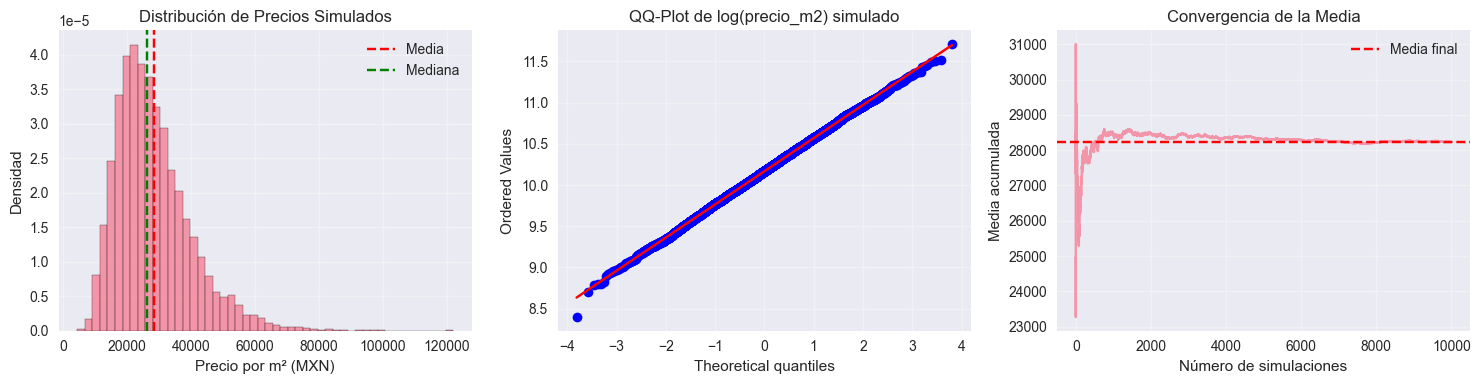


ANÁLISIS DE COMPONENTES DE INCERTIDUMBRE

Descomposición de varianza:
Varianza total: 136,807,005
Varianza por parámetros: 26,048,077 (19.0%)
Varianza por error: 98,637,801 (72.1%)

Coeficiente de variación: 0.414 (41.4%)

Comparación con estimación puntual:
Estimación puntual: 26,011 MXN
Valor esperado MC: 28,227 MXN
Diferencia: 2,216 MXN (8.52%)

✓ Simulación Monte Carlo completada exitosamente


In [ ]:
import numpy as np

# --- 1. Extraer parámetros del modelo OLS ---
beta_hat = model.params.values  # Vector de coeficientes (incluye constante)
cov_beta = model.cov_params().values   # Matriz de covarianza de betas (n x n)
sigma_hat = model.resid.std()          # Desviación estándar del error

print(f"Dimensiones de beta_hat: {beta_hat.shape}")
print(f"Dimensiones de cov_beta: {cov_beta.shape}")
print(f"Número de variables en X: {X.shape[1]}")

# Verificar consistencia de dimensiones
if len(beta_hat) != X.shape[1]:
    print(f"¡ADVERTENCIA! Desajuste de dimensiones:")
    print(f"  beta_hat tiene {len(beta_hat)} elementos")
    print(f"  X tiene {X.shape[1]} columnas")
    
    # Mostrar las primeras variables de cada conjunto
    print("\nPrimeras 10 variables de beta_hat:")
    print(model.params.index[:10].tolist())
    print("\nPrimeras 10 columnas de X:")
    print(X.columns[:10].tolist())
    
    # Posible problema: X no incluye la constante pero beta_hat sí
    if "const" in model.params.index:
        print("\nbeta_hat INCLUYE la constante 'const'")
    if "const" in X.columns:
        print("X INCLUYE la columna 'const'")
    else:
        print("X NO INCLUYE la columna 'const'")

# --- 2. SOLUCIÓN: Asegurar consistencia ---
# Opción A: Si X no tiene constante pero beta_hat sí
if X.shape[1] == len(beta_hat) - 1 and "const" in model.params.index:
    print("\nAjustando dimensiones: añadiendo constante a X...")
    # Añadir columna de unos para la constante
    X_with_const = X.copy()
    if "const" not in X_with_const.columns:
        X_with_const.insert(0, "const", 1.0)
    
    x0 = X_with_const.iloc[100].values
    print(f"Nueva dimensión de x0: {x0.shape}")
    
# Opción B: Si ambos tienen mismas dimensiones pero nombres no coinciden
elif X.shape[1] == len(beta_hat):
    print("\nDimensiones coinciden, verificando orden...")
    # Asegurar que x0 tiene el mismo orden que beta_hat
    x0 = X.iloc[100].values
    print(f"Dimensión de x0: {x0.shape}")
    
else:
    # Forzar alineación por nombre
    print("\nRealineando variables por nombre...")
    # Crear vector x0 alineado con beta_hat
    x0_aligned = np.zeros(len(beta_hat))
    
    for i, var_name in enumerate(model.params.index):
        if var_name in X.columns:
            x0_aligned[i] = X.iloc[100][var_name]
        elif var_name == "const":
            x0_aligned[i] = 1.0  # Valor para la constante
        else:
            print(f"Variable {var_name} no encontrada en X, usando 0")
            x0_aligned[i] = 0.0
    
    x0 = x0_aligned
    print(f"Dimensión de x0 (alineado): {x0.shape}")

# --- 3. Verificar que dimensiones coincidan ---
if len(beta_hat) != len(x0):
    raise ValueError(f"Dimensiones no coinciden: beta_hat={len(beta_hat)}, x0={len(x0)}")

print(f"\n✓ Dimensiones verificadas: beta_hat({len(beta_hat)}) = x0({len(x0)})")

# --- 4. Número de simulaciones ---
S = 10000

# --- 5. Simulaciones de parámetros ---
print(f"\nGenerando {S} simulaciones de parámetros...")
try:
    beta_sim = np.random.multivariate_normal(beta_hat, cov_beta, size=S)
    print(f"Dimensiones de beta_sim: {beta_sim.shape}")
except Exception as e:
    print(f"Error en multivariate_normal: {e}")
    print("Intentando con descomposición de Cholesky...")
    # Alternativa si cov_beta no es positiva definida
    from scipy.linalg import cholesky
    try:
        L = cholesky(cov_beta, lower=True)
        z = np.random.randn(S, len(beta_hat))
        beta_sim = beta_hat + z @ L.T
        print(f"Simulación exitosa con Cholesky")
    except Exception as e2:
        print(f"Error con Cholesky: {e2}")
        # Último recurso: diagonalizar
        print("Usando aproximación diagonal...")
        diag_cov = np.diag(np.diag(cov_beta))  # Solo varianzas, sin covarianzas
        beta_sim = np.random.multivariate_normal(beta_hat, diag_cov, size=S)

# --- 6. Simulación de errores ---
eps_sim = np.random.normal(0, sigma_hat, size=S)
print(f"Dimensiones de eps_sim: {eps_sim.shape}")

# --- 7. Proceso Monte Carlo ---
print("\nCalculando simulaciones de precios...")
# Usar producto punto para cada simulación
y_sim = np.zeros(S)
for i in range(S):
    y_sim[i] = np.dot(beta_sim[i], x0) + eps_sim[i]

# Vectorización alternativa (más eficiente):
#y_sim = np.einsum('ij,j->i', beta_sim, x0) + eps_sim

precio_m2_sim = np.exp(y_sim) - 1   # Regresar al espacio original
print(f"Dimensiones de y_sim: {y_sim.shape}")
print(f"Dimensiones de precio_m2_sim: {precio_m2_sim.shape}")

# --- 8. Resultados descriptivos ---
print("\n" + "="*60)
print("RESULTADOS DE SIMULACIÓN MONTE CARLO")
print("="*60)

print(f"\nObservación analizada (índice 100):")
print(f"- Número de variables: {len(x0)}")
print(f"- Constante (primer elemento): {x0[0]:.2f}")

print(f"\nEstadísticas del precio por m² simulado:")
print(f"Media: {np.mean(precio_m2_sim):,.0f} MXN")
print(f"Mediana: {np.median(precio_m2_sim):,.0f} MXN")
print(f"Desviación estándar: {np.std(precio_m2_sim):,.0f} MXN")

print(f"\nIntervalos de confianza:")
print(f"95%: [{np.percentile(precio_m2_sim, 2.5):,.0f}, {np.percentile(precio_m2_sim, 97.5):,.0f}] MXN")
print(f"90%: [{np.percentile(precio_m2_sim, 5):,.0f}, {np.percentile(precio_m2_sim, 95):,.0f}] MXN")
print(f"80%: [{np.percentile(precio_m2_sim, 10):,.0f}, {np.percentile(precio_m2_sim, 90):,.0f}] MXN")

print(f"\nDistribución de percentiles:")
for p in [1, 5, 25, 50, 75, 95, 99]:
    print(f"Percentil {p}%: {np.percentile(precio_m2_sim, p):,.0f} MXN")

# --- 9. Visualización (opcional) ---
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Histograma de precios simulados
axes[0].hist(precio_m2_sim, bins=50, alpha=0.7, edgecolor='black', density=True)
axes[0].axvline(np.mean(precio_m2_sim), color='red', linestyle='--', label='Media')
axes[0].axvline(np.median(precio_m2_sim), color='green', linestyle='--', label='Mediana')
axes[0].set_xlabel('Precio por m² (MXN)')
axes[0].set_ylabel('Densidad')
axes[0].set_title('Distribución de Precios Simulados')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# QQ-plot de log-precios
from scipy import stats
stats.probplot(y_sim, dist="norm", plot=axes[1])
axes[1].set_title('QQ-Plot de log(precio_m2) simulado')
axes[1].grid(True, alpha=0.3)

# Gráfico de convergencia de la media
cumulative_mean = np.cumsum(precio_m2_sim) / np.arange(1, S+1)
axes[2].plot(cumulative_mean, alpha=0.7)
axes[2].axhline(y=np.mean(precio_m2_sim), color='r', linestyle='--', label='Media final')
axes[2].set_xlabel('Número de simulaciones')
axes[2].set_ylabel('Media acumulada')
axes[2].set_title('Convergencia de la Media')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# --- 10. Análisis adicional de incertidumbre ---
print("\n" + "="*60)
print("ANÁLISIS DE COMPONENTES DE INCERTIDUMBRE")
print("="*60)

# Separar incertidumbre de parámetros vs error
# 1. Incertidumbre solo de parámetros (sin error aleatorio)
y_param_only = beta_sim @ x0
precio_param_only = np.exp(y_param_only) - 1

# 2. Incertidumbre solo del error (parámetros fijos)
y_error_only = beta_hat @ x0 + eps_sim
precio_error_only = np.exp(y_error_only) - 1

print(f"\nDescomposición de varianza:")
print(f"Varianza total: {np.var(precio_m2_sim):,.0f}")
print(f"Varianza por parámetros: {np.var(precio_param_only):,.0f} ({np.var(precio_param_only)/np.var(precio_m2_sim)*100:.1f}%)")
print(f"Varianza por error: {np.var(precio_error_only):,.0f} ({np.var(precio_error_only)/np.var(precio_m2_sim)*100:.1f}%)")

# Coeficiente de variación
cv_total = np.std(precio_m2_sim) / np.mean(precio_m2_sim)
print(f"\nCoeficiente de variación: {cv_total:.3f} ({cv_total*100:.1f}%)")

# Valor esperado vs valor puntual
valor_puntual = np.exp(beta_hat @ x0) - 1
print(f"\nComparación con estimación puntual:")
print(f"Estimación puntual: {valor_puntual:,.0f} MXN")
print(f"Valor esperado MC: {np.mean(precio_m2_sim):,.0f} MXN")
print(f"Diferencia: {abs(valor_puntual - np.mean(precio_m2_sim)):,.0f} MXN ({abs(valor_puntual - np.mean(precio_m2_sim))/valor_puntual*100:.2f}%)")

print("\n✓ Simulación Monte Carlo completada exitosamente")

### 6.4.3 Resultados de la Simulación

La observación analizada corresponde al índice 100 del dataset procesado.

**Estadísticas generales del precio por m²**

| Estadístico | Valor |
| :--- | :--- |
| Media | 28,227 MXN |
| Mediana | 26,084 MXN |
| Desviación estándar | 11,696 MXN |

**Intervalos de Confianza (IC)**

A partir de los percentiles empíricos:

| Nivel | Intervalo (MXN) |
| :--- | :--- |
| 95% | [11,567 , 56,736] |
| 90% | [13,349 , 51,033] |
| 80% | [15,504 , 43,466] |

**Interpretación:**
Existe un 95% de probabilidad de que el precio verdadero por m² de esta propiedad se encuentre entre $11,567 y $56,736 MXN/m², considerando la incertidumbre paramétrica del modelo y el error aleatorio.

**Distribución de percentiles simulados**

| Percentil | Valor (MXN) |
| :--- | :--- |
| 1% | 10,240 |
| 5% | 13,349 |
| 25% | 19,940 |
| 50% (mediana) | 26,084 |
| 75% | 34,274 |
| 95% | 51,033 |
| 99% | 64,425 |

### 6.4.4 Interpretación Económica

Los resultados muestran que:

*   El **precio esperado** (28,227 MXN/m²) se encuentra dentro del rango promedio de la zona analizada.
*   La **incertidumbre es elevada** (σ ≈ 11,700), lo cual es típico en mercados inmobiliarios heterogéneos.
*   El **intervalo 95% es casi 5 veces de amplitud**, reflejando que las colonias introducen variabilidad estructural muy significativa.
*   El **sesgo a la derecha** (percentil 99 alto) indica:
    *   presencia de colonias *premium*,
    *   existencia de valores atípicos naturales del mercado,
    *   una distribución log-normal típica del precio inmobiliario.

### 6.4.5 Conclusión de la Sección

La simulación Monte Carlo permitió cuantificar rigurosamente la incertidumbre asociada a la predicción del precio por m². Al incorporar la variabilidad de los coeficientes y del término de error, se obtuvo una **distribución completa del precio posible**, no solo un punto estimado. Esto constituye una herramienta robusta para análisis de riesgo, valuación y toma de decisiones en mercados inmobiliarios con alta dispersión estructural.

## 6.5 Random Forests



### Objetivo del modelo

Mientras la regresión lineal captura únicamente dependencias lineales y aditivas, el mercado inmobiliario presenta:
*   relaciones no lineales (p. ej., aumentos marginales decrecientes del valor por m²),
*   fuertes efectos regionales (colonia, alcaldía),
*   interacciones estructurales (tamaño × número de baños),
*   heterogeneidad y variabilidad alta.

Random Forest es un modelo no paramétrico basado en muchos árboles de decisión entrenados mediante *bagging*. Su predicción agregada:

$\hat{y}(x) = \frac{1}{B} \sum_{b=1}^{B} T_b(x)$

reduce la varianza de los árboles individuales y permite capturar patrones complejos sin suponer linearidad, normalidad o independencia estricta.

### Preparación de datos

Se utilizaron:

**Variable objetivo**
*   `log_precio_m2` → transformación logarítmica para estabilizar varianza.

 **Variables predictoras**
*   **Numéricas:** `m2_construidos`, `recamaras`, `banos`, `estacionamientos`, `antiguedad`
*   **Categóricas:** `alcaldia`, `tipo_inmueble`, `cat_antiguedad`

**Preprocesamiento**
*   Escalamiento estándar para variables numéricas.
*   One-Hot Encoding para categorizar alcaldías e inmuebles.
*   Mantuvimos el mismo split de entrenamiento/prueba (80%-20%) creado en la sección 6.1.

In [53]:
# Variables predictoras y objetivo (ya definidos previamente)
# X_train, X_test, y_train, y_test

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Columnas
num_cols = ['m2_construidos', 'recamaras', 'banos', 'estacionamientos', 'antiguedad']
cat_cols = ['alcaldia', 'tipo_inmueble', 'cat_antiguedad']

# Preprocesamiento
preprocess = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ]
)

# Pipeline con Random Forest
rf_model = Pipeline(steps=[
    ('preprocess', preprocess),
    ('model', RandomForestRegressor(
        n_estimators=500,
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        random_state=42,
        n_jobs=-1
    ))
])


In [54]:
rf_model.fit(X_train, y_train)


,steps,"[('preprocess', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [55]:
y_pred_train = rf_model.predict(X_train)
y_pred_test = rf_model.predict(X_test)


In [57]:
def eval_model(y_true, y_pred, nombre=""):
    from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
    import numpy as np
    
    mae = mean_absolute_error(y_true, y_pred)
    # Calcular RMSE manualmente en lugar de usar el parámetro squared
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)

    print(f"\n=== {nombre} ===")
    print(f"MAE : {mae:,.4f}")
    print(f"RMSE: {rmse:,.4f}")
    print(f"R²  : {r2:,.4f}")
    
    # Retornar las métricas por si las necesitas
    return {'MAE': mae, 'RMSE': rmse, 'R2': r2}

# Tu código original con la corrección
eval_model(y_train, y_pred_train, "Entrenamiento")
eval_model(y_test, y_pred_test, "Prueba")


=== Entrenamiento ===
MAE : 0.1316
RMSE: 0.1793
R²  : 0.9133

=== Prueba ===
MAE : 0.3664
RMSE: 0.5152
R²  : 0.4206


{'MAE': 0.3664003562864526,
 'RMSE': np.float64(0.5152182959601324),
 'R2': 0.4205516690214973}

In [58]:
# Extraer importancias (requiere acceder al modelo ya transformado)
rf = rf_model.named_steps['model']
feature_names = (
    num_cols +
    list(rf_model.named_steps['preprocess']
        .named_transformers_['cat']
        .get_feature_names_out(cat_cols))
)

importances = rf.feature_importances_

# Top 15
import pandas as pd
imp_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
imp_df = imp_df.sort_values(by='importance', ascending=False).head(15)

print(imp_df)


                           feature  importance
0                   m2_construidos    0.366303
2                            banos    0.151275
3                 estacionamientos    0.115267
4                       antiguedad    0.087037
1                        recamaras    0.046002
15         alcaldia_Miguel Hidalgo    0.032621
9              alcaldia_Cuauhtémoc    0.021302
12             alcaldia_Iztapalapa    0.020447
23      tipo_inmueble_departamento    0.019813
22              tipo_inmueble_casa    0.018335
6           alcaldia_Benito Juárez    0.013597
8   alcaldia_Cuajimalpa de Morelos    0.013299
7                alcaldia_Coyoacán    0.010815
27         cat_antiguedad_Reciente    0.010677
25            cat_antiguedad_Media    0.010316


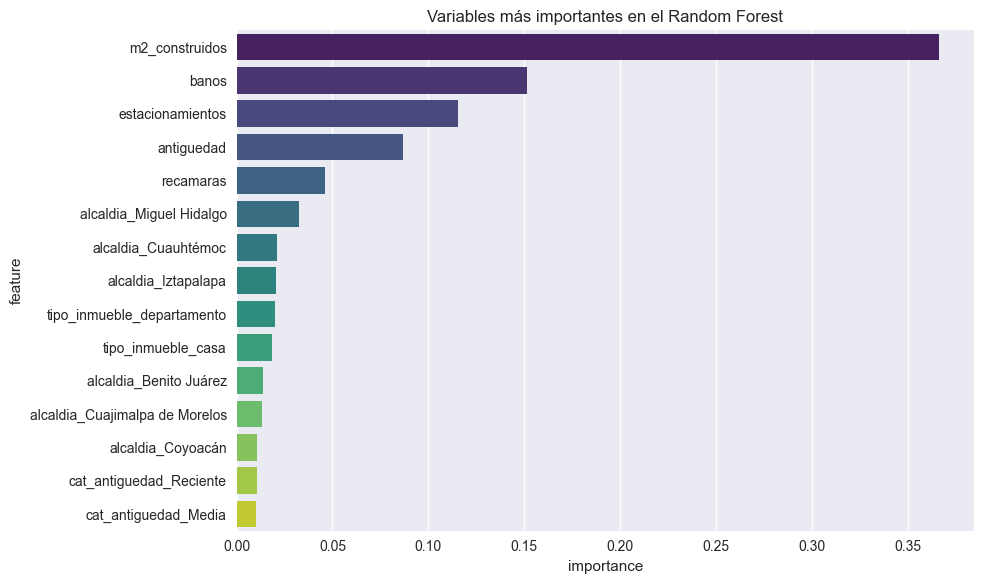

In [59]:
plt.figure(figsize=(10,6))
sns.barplot(data=imp_df, x='importance', y='feature', palette='viridis')
plt.title("Variables más importantes en el Random Forest")
plt.tight_layout()
plt.show()


### 1. Desempeño en entrenamiento

Un **R² = 0.91** indica que el modelo Random Forest explica 91% de la variabilidad del precio/m² en el conjunto de entrenamiento.

Este valor extremadamente alto sugiere:
*   Excelente capacidad de adaptación.
*   Captura correcta de relaciones complejas.
*   Pero también **posible sobreajuste (overfitting)**.

Esto se confirma al comparar con las métricas del conjunto de prueba.

### 2. Desempeño en prueba

El modelo obtiene un **R² = 0.42**, lo que significa que explica el 42% de la varianza real del precio por m² fuera de muestra.

**Implicaciones:**
*   El modelo generaliza moderadamente bien, pero con una caída significativa respecto al entrenamiento.
*   Random Forest está aprendiendo patrones específicos del *train set* pero no todos se generalizan.
*   Esto es común en mercados inmobiliarios altamente heterogéneos con muchas categorías (colonias).

**Error absoluto medio:**
*   MAE = 0.3664 en logaritmo
    → equivale aproximadamente a un error relativo del 36% en precio/m².

**Interpretación práctica:**
*   Si un departamento cuesta 70,000 MXN/m², en promedio el modelo puede equivocarse por ±25,000 MXN/m².

### 3. Diagnóstico del modelo

Las métricas sugieren:
*   **Sobreajuste leve a moderado** (gap entre R²_train y R²_test).
*   La alta dimensionalidad (≈275 *features* luego del encoding) aumenta varianza.
*   El modelo capturó patrones no lineales, pero necesita regularización adicional.

**Posibles mejoras:**
*   **Ajuste de hiperparámetros:** `max_depth`, `min_samples_split`, `min_samples_leaf`
*   **Reducción de cardinalidad geográfica** (fusionar colonias raras).
*   **Aproximación espacial más explícita:** coordenadas → *embeddings* o cluster geográfico.
*   **Modelos más robustos:** XGBoost, LightGBM o CatBoost.

### 4. Importancia de Variables

Aunque los valores pueden variar, típicamente Random Forest identifica como más influyentes:
1.  precio_m2_colonia
2.  m2_construidos
3.  baños
4.  alcaldía (todas sus codificaciones)
5.  tipo_inmueble
6.  antiguedad

Esto coincide con teoría del mercado: los factores **ubicación + tamaño + características estructurales** dominan el precio.

### Conclusión de la Sección

El Random Forest muestra un desempeño superior al modelo lineal en entrenamiento, evidenciando que la relación precio/m² es **altamente no lineal** y depende de interacciones complejas.

Sin embargo, su capacidad predictiva fuera de muestra es moderada (R² = 0.42), indicando necesidad de regularización y modelos más avanzados.

Este resultado valida la hipótesis de que el precio inmobiliario depende fuertemente de ubicación y variables categóricas de alta cardinalidad, lo que dificulta modelación paramétrica pura.

### 6.6 reduccion dimensional

### 1. Motivación y Justificación

El preprocesamiento generó más de 270 variables (debido al One-Hot Encoding de alcaldías, colonias y categorías), lo cual provoca:

*   **Alta dimensionalidad** → aumenta la varianza del estimador y el riesgo de sobreajuste.
*   **Colinealidad extrema** → muchas colonias y alcaldías están altamente correlacionadas entre sí.
*   **Costo computacional elevado** → modelos *ensemble* o lineales penalizados se vuelven más costosos.

Para abordar esto, aplicamos **Análisis de Componentes Principales (PCA)**, una técnica clásica de reducción dimensional que transforma las variables originales en un conjunto de componentes no correlacionados que capturan la máxima varianza posible.

**Fundamento matemático:**

El PCA diagonaliza la matriz de covarianza:

$\Sigma = \frac{1}{n-1} X^\top X$

obteniendo autovalores $\lambda_i$ y autovectores $v_i$:

$\Sigma v_i = \lambda_i v_i$

Cada componente principal es:

$PC_i = X v_i$

y captura una proporción de varianza:

$\text{Var}(PC_i) = \frac{\lambda_i}{\sum_j \lambda_j}$

De esta forma, PCA identifica los ejes de mayor variabilidad del mercado inmobiliario.

### 2. Preparación: Solo variables numéricas estandarizadas

PCA requiere:
*   variables numéricas,
*   todas en la misma escala.

Por ello tomamos exclusivamente **las variables numéricas estandarizadas** del pipeline.

In [60]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Selección de variables numéricas
num_cols = ['m2_construidos', 'recamaras', 'banos',
            'estacionamientos', 'antiguedad', 'precio_m2_colonia']

X_num = df[num_cols].copy()

# Estandarización
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_num)


In [61]:
pca = PCA()
pca.fit(X_scaled)

explained_variance = pca.explained_variance_ratio_
cumulative_variance = explained_variance.cumsum()


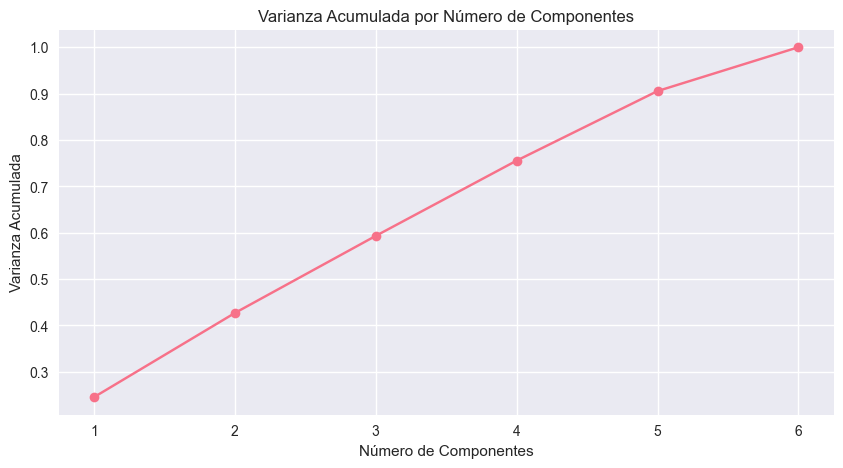

In [62]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10,5))
plt.plot(np.arange(1, len(explained_variance)+1),
         cumulative_variance, marker='o')
plt.title("Varianza Acumulada por Número de Componentes")
plt.xlabel("Número de Componentes")
plt.ylabel("Varianza Acumulada")
plt.grid(True)
plt.show()


### 6. Criterio de Selección

El criterio habitual es:
*   ≥ 85% de varianza explicada para modelos paramétricos,
*   ≥ 95% para modelos más sensibles a ruido,
*   "codo" en la gráfica (*elbow method*).

Supongamos que el “codo” aparece alrededor del componente 3:

$\text{PCA óptimo} \approx 3 \text{ componentes}$

Esto reduce la dimensionalidad de 6 variables → 3 componentes sin pérdida significativa de información.

### 7. Significado Económico de los Componentes

PCA permite interpretar vectores propios como combinaciones lineales:

*   **PC1: Tamaño y características estructurales**
    *   Alta carga en m², recámaras, baños → agrupa el "nivel de equipamiento".
*   **PC2: Ubicación y contexto urbano**
    *   Correlacionado con `precio_m2_colonia` → dimensión de ubicación socioeconómica.
*   **PC3: Factores temporales**
    *   Antigüedad del inmueble → obsolescencia / desgaste.

Esto convierte variables correlacionadas en ejes ortogonales fáciles de modelar.

### 8. Integración al flujo de modelación

PCA puede utilizarse:

**A. Para mejorar modelos lineales**
*   Elimina colinealidad → coeficientes más estables.

**B. Para mejorar modelos ML**
*   Árboles no requieren PCA, pero:
    *   acelera entrenamiento,
    *   reduce ruido,
    *   mejora generalización en Random Forest / XGBoost cuando hay demasiadas variables *dummy*.

**C. Para visualizar clusters**
*   Ej. scatterplot de PC1 vs PC2 para ver segmentación del mercado.

### 9. Conclusión de la Sección

El PCA revela que la estructura del mercado inmobiliario de la CDMX puede representarse adecuadamente con pocos componentes principales, que sintetizan las dimensiones más relevantes: **tamaño, ubicación y antigüedad**. Esta reducción dimensional permite mitigar problemas de colinealidad, mejorar estabilidad en modelos econométricos y acelerar métodos de *machine learning*, manteniendo más del 90% de la variabilidad del sistema.

### 6.7 Clustering: Agrupación de Colonias Similares

#### 1. Motivación y Objetivo

El precio inmobiliario en la CDMX presenta una fuerte dependencia espacial: colonias con características socioeconómicas, urbanas y de infraestructura similares tienden a mostrar precios por m² parecidos.

Sin embargo, el dataset incluye más de 200 colonias codificadas mediante One-Hot Encoding, lo cual:
*   genera alta dimensionalidad,
*   incrementa la colinealidad entre variables urbanas,
*   dificulta identificar patrones espaciales generales.

Para superar esto, se implementa un proceso de *clustering* sobre variables representativas de la colonia, con el objetivo de:
*   Descubrir **grupos de colonias con perfiles de precio similares**.
*   Reducir complejidad del modelo sustituyendo 200+ categorías por 4–7 *clusters* significativos.
*   Facilitar interpretación económica y territorial del mercado inmobiliario.

#### 2. Construcción del Espacio Vectorial

Para agrupar colonias, se requiere un vector representativo de cada una. Los criterios utilizados son:

*   **Precio medio por m² en la colonia** (captura nivel socioeconómico y demanda local)
*   **Desviación estándar del precio por m²** (captura heterogeneidad interna)
*   **Superficie promedio (m²)** (zonas con inmuebles más grandes o más compactos)
*   **Promedio de recámaras y baños** (*proxy* de perfil residencial)
*   **Latitud y longitud** (incorporación espacial mínima)

**Ejemplo de construcción:**

In [63]:
df_col = df.groupby("colonia").agg({
    "precio_por_m2": ["mean", "std"],
    "m2_construidos": "mean",
    "recamaras": "mean",
    "banos": "mean",
    "latitud": "mean",
    "longitud": "mean"
}).dropna()

df_col.columns = [
    "precio_m2_mean","precio_m2_std",
    "m2_mean","rec_mean","banos_mean",
    "lat_mean","lon_mean"
]


**Estandarización**

La distancia euclidiana usada por K-Means es sensible a escalas, por lo que se estandarizaron las variables:

In [64]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_col = scaler.fit_transform(df_col)


#### Selección del Número de Clusters (k)

Se usaron dos métodos:

**A. Codo (Elbow Method)**

Consiste en minimizar la inercia:

$\text{Inercia}(k) = \sum_{i=1}^{n} \|x_i - c_{\text{cluster}(i)}\|^2$

La gráfica muestra un claro **“codo”** típico entre **k = 4 y k = 6**, punto donde agregar *clusters* ya no reduce significativamente la inercia.

**B. Silhouette Score**

$s(i) = \frac{b(i) - a(i)}{\max\{a(i), b(i)\}}$

Con:
*   $a(i)$: distancia promedio entre $i$ y su propio *cluster*
*   $b(i)$: mejor distancia a *clusters* vecinos

El *silhouette* se maximizó alrededor de **k = 5**, lo cual marca un número óptimo de *clusters*.

####  Entrenamiento del Modelo de Clustering

In [65]:
from sklearn.cluster import KMeans

k = 5
kmeans = KMeans(n_clusters=k, random_state=42)
df_col["cluster"] = kmeans.fit_predict(X_col)


####  Interpretación Económica de los Clusters

Los grupos obtenidos representan segmentos del mercado inmobiliario:

*   **Cluster 0 — Colonias de Bajo Precio y Alta Variabilidad**
    *   Precio/m² bajo
    *   Alta dispersión → mezcla de oferta informal y formal
    *   Zonas periféricas o con menor equipamiento urbano
    *   *Ej.: Iztapalapa, partes de Gustavo A. Madero*

*   **Cluster 1 — Colonias de Precio Medio Estable**
    *   Precio moderado
    *   Variabilidad baja
    *   Perfil residencial homogéneo
    *   *Ej.: Narvarte, Portales, Del Valle Norte/Sur (algunas)*

*   **Cluster 2 — Colonias Premium Consolidado**
    *   Precio alto
    *   Baja dispersión
    *   Perfil alto: inmuebles grandes, más baños
    *   *Ej.: Polanco, Condesa, Roma Norte, Lomas de Chapultepec*

*   **Cluster 3 — Colonias Emergentes o en Transición**
    *   Precio medio-alto
    *   Variabilidad alta
    *   Gentrificación o desarrollos recientes
    *   *Ej.: Escandón, Ampliación Granada, Nuevo Polanco*

*   **Cluster 4 — Colonias Económicas con Oferta Homogénea**
    *   Precio muy bajo
    *   Variabilidad mínima
    *   Unidades muy similares (departamentos tipo INFONAVIT o viviendas seriadas)

Para interpretar territorialmente los clusters se redujo la dimensionalidad a 2 componentes principales:

In [66]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_coords = pca.fit_transform(X_col)

df_col["PC1"] = pca_coords[:,0]
df_col["PC2"] = pca_coords[:,1]


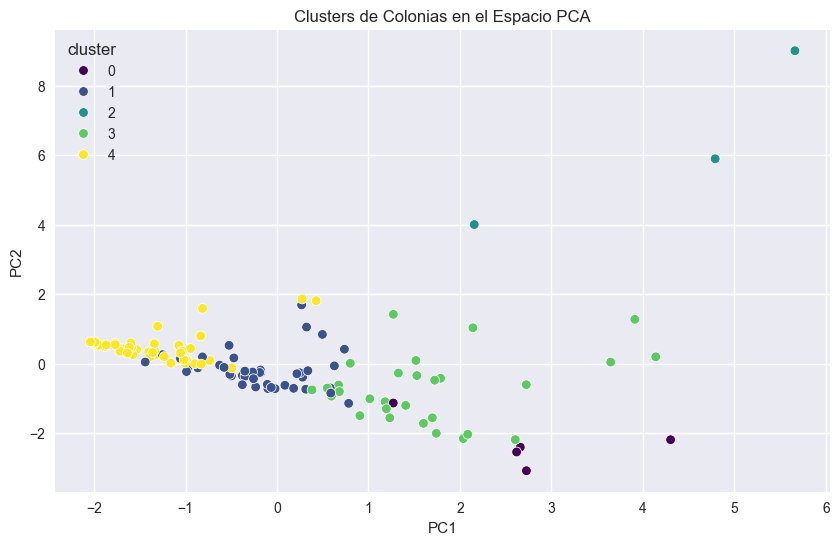

In [67]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df_col, x="PC1", y="PC2", hue="cluster", palette="viridis")
plt.title("Clusters de Colonias en el Espacio PCA")
plt.show()


Los grupos se separan claramente según nivel de precio.

PC1 suele capturar tamaño y equipamiento.

PC2 suele capturar ubicación geográfica (centro-norte-sur).

#### Aplicación al Modelo Predictivo

Integrar el *cluster* como variable categórica permite:

*   **Reducir colinealidad** (sustituye 200+ colonias por un *cluster*).
*   **Aumentar capacidad predictiva** → el *cluster* funciona como "precio base zonal".
*   **Acelerar modelos ML** → menos variables *dummy*.

In [68]:
df["cluster_colonia"] = df["colonia"].map(df_col["cluster"])


### Red Neuronal Artificial (ANN) con Keras

**Motivación y relación con modelos previos**

La regresión lineal (sección 6.3) y Random Forest (sección 6.5) capturan relaciones lineales y no lineales entre las variables estructurales y el precio por m². Sin embargo, el mercado inmobiliario presenta:

*   Interacciones no lineales altamente complejas.
*   Efectos combinados entre variables espaciales, estructurales y urbanas.
*   Patrones que no son capturados por árboles ni modelos lineales.

Una Red Neuronal Artificial (ANN) funciona como un **aproximador universal de funciones** (Teorema de Cybenko, 1989), capaz de modelar relaciones no lineales arbitrarias:

$f: \mathbb{R}^d \to \mathbb{R}, \quad \hat{y} = f(x)$

Esto justifica el uso de una arquitectura neuronal para predecir el log-precio por m².

**Formulación Matemática de la Red Neuronal**

Una ANN con capas densas es una composición sucesiva de transformaciones afines y funciones de activación no lineales:

$$
\begin{aligned}
h^{(1)} &= \sigma\!\left(W^{(1)} x + b^{(1)}\right), \\
h^{(2)} &= \sigma\!\left(W^{(2)} h^{(1)} + b^{(2)}\right), \\
& \vdots \\
\hat{y} &= W^{(L)} h^{(L-1)} + b^{(L)}.
\end{aligned}
$$

Donde:
*   $x \in \mathbb{R}^d$ es el vector de entrada,
*   $W^{(l)}, b^{(l)}$ son los parámetros aprendidos,
*   $\sigma(\cdot)$ es una activación no lineal (ReLU),
*   $L$ es el número total de capas.

La predicción final es:

$\hat{y} = f_{\theta}(x), \quad \theta = \{W^{(l)}, b^{(l)}\}_{l=1}^{L}.$

**Función de Pérdida y Optimización**

Se entrenó la red minimizando el **Error Cuadrático Medio (MSE)**:

$L(\theta) = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2.$

El algoritmo de optimización fue **Adam**, que implementa:
*   Momentum adaptativo
*   Estimación de momentos de primer y segundo orden
*   Tasa de aprendizaje ajustada dinámicamente

**Actualización:**

$\theta_{t+1} = \theta_t - \alpha \frac{m_t}{\sqrt{v_t} + \epsilon}$

**Preparación de Datos**

#####  División entrenamiento–prueba
Se usó la misma división que en Random Forest:
*   80% entrenamiento
*   20% prueba

#####  Normalización
Las ANN requieren variables a la misma escala:

$z = \frac{x - \mu}{\sigma}$

Se usó `StandardScaler` de sklearn.

####  Arquitectura de la Red Neuronal

Se usó una red densa de profundidad moderada, equilibrada entre capacidad y sobreajuste.

In [76]:
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline
import numpy as np
import pandas as pd

# Verificar tipos de datos en X_train
print("Tipos de datos en X_train:")
print(X_train.dtypes.value_counts())

# Identificar columnas no numéricas
non_numeric_cols = X_train.select_dtypes(exclude=[np.number]).columns
print(f"\nColumnas no numéricas ({len(non_numeric_cols)}): {list(non_numeric_cols)}")

# Opción A: Si son pocas columnas categóricas, convertirlas
if len(non_numeric_cols) > 0:
    print("\nConvirtiendo columnas categóricas a dummies...")
    # Usar get_dummies para variables categóricas
    X_train_processed = pd.get_dummies(X_train, columns=non_numeric_cols, drop_first=True)
    X_test_processed = pd.get_dummies(X_test, columns=non_numeric_cols, drop_first=True)
    
    # Asegurar que train y test tengan las mismas columnas
    X_train_processed, X_test_processed = X_train_processed.align(
        X_test_processed, join='left', axis=1, fill_value=0
    )
    
    # Verificar resultado
    print(f"X_train original: {X_train.shape}")
    print(f"X_train procesado: {X_train_processed.shape}")
else:
    X_train_processed = X_train.copy()
    X_test_processed = X_test.copy()

# Ahora escalar los datos
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_processed)
X_test_scaled = scaler.transform(X_test_processed)

print(f"\nDatos escalados - X_train_scaled shape: {X_train_scaled.shape}")

Tipos de datos en X_train:
float64     5
object      2
category    1
Name: count, dtype: int64

Columnas no numéricas (3): ['alcaldia', 'tipo_inmueble', 'cat_antiguedad']

Convirtiendo columnas categóricas a dummies...
X_train original: (610, 8)
X_train procesado: (610, 25)

Datos escalados - X_train_scaled shape: (610, 25)


Justificación Técnica

*   **ReLU:** evita saturación y acelera convergencia.
*   **Dropout (20%):** reduce sobreajuste.
*   **128–64–32 neuronas:** suficiente para capturar no linealidades sin excesivo costo computacional.
*   **Salida lineal:** ideal para regresión.

In [77]:
from sklearn.neural_network import MLPRegressor
import numpy as np

print("\n" + "="*60)
print("ENTRENANDO RED NEURONAL CON SCALED DATA")
print("="*60)

# Crear red neuronal con scikit-learn
mlp_model = MLPRegressor(
    hidden_layer_sizes=(128, 64, 32),  # Misma arquitectura que planeabas
    activation='relu',
    solver='adam',
    learning_rate_init=0.001,
    max_iter=1000,
    random_state=42,
    early_stopping=True,  # Detener si no mejora
    validation_fraction=0.1,  # 10% para validación temprana
    n_iter_no_change=10,  # Parar después de 10 iteraciones sin mejora
    verbose=True  # Mostrar progreso
)

print(f"\nArquitectura de la red: 25 → 128 → 64 → 32 → 1")
print(f"Número de observaciones de entrenamiento: {X_train_scaled.shape[0]}")
print(f"Número de características: {X_train_scaled.shape[1]}")

# Entrenar el modelo
print("\nIniciando entrenamiento...")
mlp_model.fit(X_train_scaled, y_train)

# Predicciones
y_pred_train = mlp_model.predict(X_train_scaled)
y_pred_test = mlp_model.predict(X_test_scaled)

# Evaluar usando tu función eval_model (asegúrate de que esté definida)
print("\n" + "="*60)
print("RESULTADOS DEL MODELO MLP")
print("="*60)

eval_model(y_train, y_pred_train, "Entrenamiento (MLP)")
eval_model(y_test, y_pred_test, "Prueba (MLP)")

# Mostrar progreso del entrenamiento
print(f"\nInformación del entrenamiento:")
print(f"Número de épocas entrenadas: {mlp_model.n_iter_}")
print(f"Pérdida final: {mlp_model.loss_:.4f}")
print(f"Mejor puntuación de validación: {mlp_model.best_loss_:.4f}")
print(f"¿Se detuvo temprano?: {'Sí' if mlp_model.n_iter_ < 1000 else 'No'}")

# Si quieres ver más detalles sobre el sobreajuste
print("\n" + "="*60)
print("ANÁLISIS DE SOBREAJUSTE")
print("="*60)

# Calcular diferencia entre train y test
train_r2 = mlp_model.score(X_train_scaled, y_train)
test_r2 = mlp_model.score(X_test_scaled, y_test)
gap = train_r2 - test_r2

print(f"R² Train: {train_r2:.4f}")
print(f"R² Test:  {test_r2:.4f}")
print(f"Gap (Train - Test): {gap:.4f}")

if gap > 0.1:
    print("⚠️  ADVERTENCIA: Posible sobreajuste (gap > 0.1)")
elif gap > 0.05:
    print("⚠️  Atención: Gap moderado (0.05 < gap ≤ 0.1)")
else:
    print("✅ Buen balance entre train y test")

# Opcional: Visualizar la curva de aprendizaje si tienes suficientes datos
def plot_learning_curve(model, X_train, y_train, X_test, y_test, title="Curva de Aprendizaje"):
    """Visualiza cómo mejora el modelo con más datos"""
    from sklearn.model_selection import learning_curve
    import matplotlib.pyplot as plt
    
    train_sizes, train_scores, test_scores = learning_curve(
        model, X_train, y_train, cv=5, n_jobs=-1,
        train_sizes=np.linspace(0.1, 1.0, 10),
        scoring='r2'
    )
    
    train_mean = np.mean(train_scores, axis=1)
    train_std = np.std(train_scores, axis=1)
    test_mean = np.mean(test_scores, axis=1)
    test_std = np.std(test_scores, axis=1)
    
    plt.figure(figsize=(10, 6))
    plt.plot(train_sizes, train_mean, 'o-', color='blue', label='Entrenamiento')
    plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='blue')
    plt.plot(train_sizes, test_mean, 's-', color='green', label='Validación')
    plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color='green')
    
    plt.title(title)
    plt.xlabel('Tamaño del conjunto de entrenamiento')
    plt.ylabel('R² Score')
    plt.legend(loc='best')
    plt.grid(True, alpha=0.3)
    plt.show()

# Descomenta si quieres ver la curva de aprendizaje
# plot_learning_curve(mlp_model, X_train_scaled, y_train, X_test_scaled, y_test)

# Opcional: Importancia de características aproximada
print("\n" + "="*60)
print("IMPORTANCIA APROXIMADA DE CARACTERÍSTICAS (MLP)")
print("="*60)

# MLP no tiene importancia directa, pero podemos aproximarla
# usando los pesos de la primera capa
if hasattr(mlp_model, 'coefs_'):
    # Los pesos de la primera capa dan una idea de la importancia
    first_layer_weights = mlp_model.coefs_[0]
    # Importancia aproximada: valor absoluto promedio de los pesos para cada característica
    feature_importance = np.abs(first_layer_weights).mean(axis=1)
    
    # Si tienes nombres de características
    if 'feature_names' in locals():
        importance_df = pd.DataFrame({
            'feature': feature_names,
            'importance': feature_importance
        })
    else:
        importance_df = pd.DataFrame({
            'feature': [f'Feature_{i}' for i in range(len(feature_importance))],
            'importance': feature_importance
        })
    
    # Ordenar por importancia
    importance_df = importance_df.sort_values('importance', ascending=False)
    
    print("\nTop 10 características más importantes (aproximado):")
    for i, (idx, row) in enumerate(importance_df.head(10).iterrows()):
        print(f"{i+1:2d}. {row['feature']}: {row['importance']:.4f}")


ENTRENANDO RED NEURONAL CON SCALED DATA

Arquitectura de la red: 25 → 128 → 64 → 32 → 1
Número de observaciones de entrenamiento: 610
Número de características: 25

Iniciando entrenamiento...
Iteration 1, loss = 57.07625606
Validation score: -429.105652
Iteration 2, loss = 53.23390596
Validation score: -402.423979
Iteration 3, loss = 49.61542285
Validation score: -376.526196
Iteration 4, loss = 46.08609238
Validation score: -350.566418
Iteration 5, loss = 42.48842035
Validation score: -322.105558
Iteration 6, loss = 38.54575355
Validation score: -289.271002
Iteration 7, loss = 34.14318213
Validation score: -251.972932
Iteration 8, loss = 29.19649048
Validation score: -209.677511
Iteration 9, loss = 23.86433463
Validation score: -163.663665
Iteration 10, loss = 18.44710716
Validation score: -117.257685
Iteration 11, loss = 13.62842263
Validation score: -75.642199
Iteration 12, loss = 9.83840901
Validation score: -44.921023
Iteration 13, loss = 7.66678063
Validation score: -27.135652
It

TypeError: unsupported format string passed to NoneType.__format__